# Oracle Agent Memory — OAMP vs Naive Memory Benchmarks (OpenAI GPT-5.5)

[![Oracle Agent Memory](https://img.shields.io/badge/Documentation-Oracle%20AI%20Agent%20Memory-red?style=flat-square)](https://www.oracle.com/database/ai-agent-memory/)
[![OpenAI GPT-5.5](https://img.shields.io/badge/Model-GPT--5.5-10a37f?style=flat-square)](https://developers.openai.com/api/docs/models/gpt-5.5)

This is a direct adaptation of Oracle's
[`oracle_agent_memory_benchmarks_oci.ipynb`](https://github.com/oracle-devrel/oracle-ai-developer-hub/blob/main/notebooks/agent_memory/oracle_agent_memory_benchmarks_oci.ipynb).
It preserves the 80-turn ChromAtlas-ND workload, Oracle Agent Memory operations, three agent patterns, compaction, offline extraction, and the original evaluation axes while replacing **OCI model inference and OCI embeddings** with direct OpenAI API calls:

- **Generation, memory extraction, summarisation, and judging:** `gpt-5.5` through the Responses API
- **Vector embeddings:** `text-embedding-3-small` through the Embeddings API
- **Durable memory and vector search:** Oracle AI Database through `oracleagentmemory`

The benchmark measures:

1. **Actual input tokens per answer call** from OpenAI's `response.usage`, not a character estimate
2. **All hot-path model tokens** so OAMP extraction and summary calls are not hidden from cost accounting
3. **Prompt-cache hits** using the provider-reported cached-token count
4. **Retrieval and end-to-end latency** for every turn
5. **Response quality** with a context-grounded, position-balanced LLM judge
6. **Offline durable-fact extraction** into Oracle Agent Memory

The default is 24 turns: enough to include the first recall questions and one compaction boundary without incurring the cost of all 80 turns. Set `MAX_BENCHMARK_TURNS=80` before running the configuration cell for the exact full-workload reproduction.

> **Prerequisites**
> - An Oracle AI Database reachable through `DB_CONNECT_STRING`
> - `OPENAI_API_KEY` in the environment, or enter it securely when prompted
> - `DB_PASSWORD` in the environment, or enter it securely when prompted
> - Python 3.11+ with the packages checked below

> **Evaluation boundary:** Oracle remains the memory provider. Only the OCI inference and embedding providers are replaced. GPT-5.5 is both the response model and judge to honor the single-model requirement; the notebook exposes this self-judge limitation rather than treating the score as human ground truth.

## 1. Verify dependencies

In [1]:
from importlib.metadata import PackageNotFoundError, version

REQUIRED_PACKAGES = {
    "oracleagentmemory": "26.6.0",
    "openai": "3.3.0",
    "oracledb": "2.0.0",
    "matplotlib": "3.8.0",
    "numpy": "1.26.0",
    "nest_asyncio": "1.6.0",
}

for package, minimum in REQUIRED_PACKAGES.items():
    try:
        installed = version(package)
    except PackageNotFoundError as exc:
        raise RuntimeError(
            f"Missing {package}. Install the notebook requirements before continuing."
        ) from exc
    print(f"{package:<20} {installed} (minimum documented version: {minimum})")

# If packages are missing, run this once in the active kernel, then restart it:
# %pip install "oracleagentmemory>=26.6,<27" "openai>=3.3,<4" "oracledb>=2" matplotlib numpy nest_asyncio

oracleagentmemory    26.6.0 (minimum documented version: 26.6.0)
openai               3.3.1 (minimum documented version: 3.3.0)
oracledb             4.0.2 (minimum documented version: 2.0.0)
matplotlib           3.11.0 (minimum documented version: 3.8.0)
numpy                2.4.6 (minimum documented version: 1.26.0)
nest_asyncio         1.6.0 (minimum documented version: 1.6.0)


In [2]:
import asyncio
import getpass
import os
from collections.abc import Sequence
from typing import Any

import nest_asyncio
import numpy as np
from openai import OpenAI
from oracleagentmemory.apis.embedders.embedder import IEmbedder
from oracleagentmemory.apis.llms.llm import ILlm, LlmResponse

nest_asyncio.apply()


def require_secret(name: str, prompt: str) -> str:
    """Read a secret from the environment or prompt without displaying it."""
    value = os.environ.get(name, "").strip()
    if not value:
        value = getpass.getpass(prompt).strip()
        if not value:
            raise RuntimeError(f"{name} is required.")
        os.environ[name] = value
    return value


OPENAI_API_KEY = require_secret("OPENAI_API_KEY", "OpenAI API key: ")
if not os.environ.get("DB_PASSWORD") and os.environ.get("ORACLE_PASSWORD"):
    os.environ["DB_PASSWORD"] = os.environ["ORACLE_PASSWORD"]
DB_PASSWORD = require_secret("DB_PASSWORD", "Oracle Database password: ")
OPENAI_MODEL = os.environ.get("OPENAI_MODEL", "gpt-5.5").strip()
OPENAI_REASONING_EFFORT = os.environ.get("OPENAI_REASONING_EFFORT", "none").strip()
OPENAI_EMBEDDING_MODEL = os.environ.get(
    "OPENAI_EMBEDDING_MODEL", "text-embedding-3-small"
).strip()
OPENAI_EMBEDDING_DIMENSIONS = int(
    os.environ.get("OPENAI_EMBEDDING_DIMENSIONS", "1536")
)

if OPENAI_MODEL != "gpt-5.5" and not OPENAI_MODEL.startswith("gpt-5.5-"):
    raise RuntimeError(
        "This reproduction requires GPT-5.5. Set OPENAI_MODEL to gpt-5.5 "
        "or a pinned GPT-5.5 snapshot."
    )

os.environ.setdefault("DB_USER", "VECTOR")
os.environ.setdefault("DB_CONNECT_STRING", "localhost:1521/FREEPDB1")

openai_client = OpenAI(api_key=OPENAI_API_KEY, timeout=180.0, max_retries=5)
OPENAI_CALL_LOG: list[dict[str, Any]] = []


class ChatText(str):
    """A normal string carrying the exact usage returned with its API response."""

    def __new__(cls, value: str, *, usage: dict[str, int]):
        instance = super().__new__(cls, value)
        instance.usage = usage
        return instance


def _usage_dict(response: Any) -> dict[str, int]:
    usage = response.usage
    input_details = getattr(usage, "input_tokens_details", None)
    output_details = getattr(usage, "output_tokens_details", None)
    return {
        "input_tokens": int(getattr(usage, "input_tokens", 0) or 0),
        "cached_tokens": int(getattr(input_details, "cached_tokens", 0) or 0),
        "output_tokens": int(getattr(usage, "output_tokens", 0) or 0),
        "reasoning_tokens": int(getattr(output_details, "reasoning_tokens", 0) or 0),
        "total_tokens": int(getattr(usage, "total_tokens", 0) or 0),
    }


def openai_chat_text(
    messages: list[dict[str, str]],
    *,
    temperature: float = 0.2,
    max_tokens: int = 1200,
    response_json_schema: dict[str, Any] | None = None,
    purpose: str = "unspecified",
    prompt_cache_key: str | None = None,
) -> ChatText:
    """Call GPT-5.5 directly and preserve provider-reported usage."""
    request: dict[str, Any] = {
        "model": OPENAI_MODEL,
        "input": messages,
        "max_output_tokens": max_tokens,
        "reasoning": {"effort": OPENAI_REASONING_EFFORT},
    }
    if OPENAI_REASONING_EFFORT == "none":
        request["temperature"] = temperature
    if prompt_cache_key:
        request["prompt_cache_key"] = prompt_cache_key
    if response_json_schema:
        request["text"] = {
            "format": {
                "type": "json_schema",
                "name": "response",
                "schema": response_json_schema,
                "strict": False,
            }
        }

    response = openai_client.responses.create(**request)
    text = response.output_text
    if not text:
        raise RuntimeError(
            f"OpenAI returned no output text for purpose={purpose!r}; "
            f"response id={response.id}."
        )
    usage = _usage_dict(response)
    OPENAI_CALL_LOG.append(
        {
            "response_id": response.id,
            "returned_model": getattr(response, "model", OPENAI_MODEL),
            "purpose": purpose,
            **usage,
        }
    )
    return ChatText(text, usage=usage)


class OpenAISdkEmbedder(IEmbedder):
    """OracleAgentMemory embedder backed directly by OpenAI embeddings."""

    def __init__(self, client: OpenAI, model: str, dimensions: int):
        self.client = client
        self.model = model
        self.dimensions = dimensions

    def embed(self, texts: list[str], *, is_query: bool = False) -> np.ndarray:
        del is_query
        response = self.client.embeddings.create(
            model=self.model,
            input=texts,
            dimensions=self.dimensions,
            encoding_format="float",
        )
        ordered = sorted(response.data, key=lambda item: item.index)
        return np.asarray([item.embedding for item in ordered], dtype=np.float32)

    async def embed_async(self, texts: list[str], *, is_query: bool = False) -> np.ndarray:
        return await asyncio.to_thread(self.embed, texts, is_query=is_query)


class OpenAISdkLlm(ILlm):
    """OracleAgentMemory LLM adapter backed directly by OpenAI Responses."""

    def __init__(
        self,
        *,
        temperature: float = 0.2,
        max_tokens: int = 1200,
        purpose: str = "oamp_memory_maintenance",
    ):
        self.temperature = temperature
        self.max_tokens = max_tokens
        self.purpose = purpose

    def generate(
        self,
        prompt: str | Sequence[dict[str, str]],
        *,
        response_json_schema: dict[str, Any] | None = None,
        **kwargs: Any,
    ) -> LlmResponse:
        messages = (
            [{"role": "user", "content": prompt}]
            if isinstance(prompt, str)
            else list(prompt)
        )
        result = openai_chat_text(
            messages,
            temperature=kwargs.get("temperature", self.temperature),
            max_tokens=kwargs.get("max_tokens", self.max_tokens),
            response_json_schema=response_json_schema,
            purpose=self.purpose,
        )
        return LlmResponse(text=str(result))

    async def generate_async(
        self,
        prompt: str | Sequence[dict[str, str]],
        *,
        response_json_schema: dict[str, Any] | None = None,
        **kwargs: Any,
    ) -> LlmResponse:
        return await asyncio.to_thread(
            self.generate,
            prompt,
            response_json_schema=response_json_schema,
            **kwargs,
        )


oamp_embedder = OpenAISdkEmbedder(
    openai_client,
    model=OPENAI_EMBEDDING_MODEL,
    dimensions=OPENAI_EMBEDDING_DIMENSIONS,
)
oamp_llm = OpenAISdkLlm()

MAX_BENCHMARK_TURNS = int(os.environ.get("MAX_BENCHMARK_TURNS", "24"))
if not 1 <= MAX_BENCHMARK_TURNS <= 80:
    raise ValueError("MAX_BENCHMARK_TURNS must be between 1 and 80.")

print("Direct OpenAI helpers ready; no OCI inference client is used.")
print(f"Response, judge, summary, extraction model: {OPENAI_MODEL}")
print(f"Reasoning effort: {OPENAI_REASONING_EFFORT}")
print(f"Embedding model: {OPENAI_EMBEDDING_MODEL} ({OPENAI_EMBEDDING_DIMENSIONS} dimensions)")
print(f"Oracle target: {os.environ['DB_USER']}@{os.environ['DB_CONNECT_STRING']}")
print(f"MAX_BENCHMARK_TURNS: {MAX_BENCHMARK_TURNS} (set to 80 for the full workload)")

Direct OpenAI helpers ready; no OCI inference client is used.
Response, judge, summary, extraction model: gpt-5.5
Reasoning effort: none
Embedding model: text-embedding-3-small (1536 dimensions)
Oracle target: VECTOR@localhost:1521/FREEPDB1
MAX_BENCHMARK_TURNS: 24 (set to 80 for the full workload)


## 2. Connect to Oracle and create an OAMP client

Oracle AI Database remains the memory system. `OpenAISdkLlm` lets Oracle Agent Memory run its extraction and context-summary work with GPT-5.5, while `OpenAISdkEmbedder` supplies vectors from the direct OpenAI Embeddings API.

The table prefix isolates this GPT-5.5 experiment from schemas created by OCI-backed or differently dimensioned embedding examples.

In [3]:
import oracledb
from oracleagentmemory.apis.thread import Message
from oracleagentmemory.core import OracleAgentMemory

connection = oracledb.connect(
    user=os.environ["DB_USER"],
    password=DB_PASSWORD,
    dsn=os.environ["DB_CONNECT_STRING"],
)

client = OracleAgentMemory(
    connection=connection,
    embedder=oamp_embedder,
    llm=oamp_llm,
    extract_memories=True,
    schema_policy="create_if_necessary",
    table_name_prefix="OAMPG55",
)

USER_ID = "benchmark-user-openai"
AGENT_ID = "benchmark-agent-openai"

for create_fn, eid, info in [
    (client.add_user, USER_ID, "Richmond - benchmarking OAMP vs naive memory with GPT-5.5."),
    (client.add_agent, AGENT_ID, "OAMP-backed GPT-5.5 research assistant for benchmarks."),
]:
    try:
        create_fn(eid, info)
    except ValueError as exc:
        if "already exists" not in str(exc):
            raise

thread = client.create_thread(
    user_id=USER_ID,
    agent_id=AGENT_ID,
    enable_context_summary=True,
    context_summary_update_frequency=2,
    memory_extraction_frequency=2,
    memory_extraction_window=4,
)
print(f"Connected to Oracle Database {connection.version}.")
print(f"OAMP thread created: {thread.thread_id}")

/var/folders/q5/mqxgw8bd5t3b68thxd06mpnm0000gn/T/ipykernel_51997/2828901174.py:11: DeprecationWarning: Inline memory extraction parameters are deprecated for OracleAgentMemory(). Use:
from oracleagentmemory.core import MemoryExtractionConfig
memory_extraction_config=MemoryExtractionConfig(extract_memories=...)
  client = OracleAgentMemory(


/var/folders/q5/mqxgw8bd5t3b68thxd06mpnm0000gn/T/ipykernel_51997/2828901174.py:11: DeprecationWarning: table_name_prefix is deprecated and will be removed in 27.1; use memory_store_id instead.
  client = OracleAgentMemory(


Connected to Oracle Database 23.26.2.0.0.
OAMP thread created: 2941b818-4396-4b62-b702-b2f1c117a46f


/var/folders/q5/mqxgw8bd5t3b68thxd06mpnm0000gn/T/ipykernel_51997/2828901174.py:33: DeprecationWarning: Inline memory extraction parameters are deprecated for OracleAgentMemory.create_thread(). Use:
from oracleagentmemory.core import MemoryExtractionConfig
memory_extraction_config=MemoryExtractionConfig(enable_context_summary=..., memory_extraction_window=..., context_summary_update_frequency=..., memory_extraction_frequency=...)
  thread = client.create_thread(


## 3. Define both agents with exact instrumentation

Both agents call GPT-5.5 directly through OpenAI's Responses API—there is no agent framework and no OCI inference client. We capture six streams per turn:

- **Answer input tokens:** exact provider usage for the user-facing answer
- **All hot-path input tokens:** answer plus OAMP extraction/summary calls
- **Cached input tokens:** the provider-reported prompt-cache portion
- **Retrieval latency:** prompt assembly and memory work before the answer
- **End-to-end latency:** query received to answer and persistence complete
- **Response text:** retained for context-grounded judging

Separating *answer tokens* from *all hot-path tokens* prevents the memory-maintenance model calls from disappearing inside the latency measurement.

In [4]:
%matplotlib inline

import time

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

SYSTEM_PROMPT = "You are a concise research assistant. Answer in 1-3 sentences."


def call_chat(
    messages: list[dict[str, str]],
    *,
    temperature: float = 0.2,
    max_tokens: int = 1200,
    response_json_schema: dict[str, Any] | None = None,
    purpose: str = "benchmark_answer",
    prompt_cache_key: str | None = None,
) -> ChatText:
    return openai_chat_text(
        messages,
        temperature=temperature,
        max_tokens=max_tokens,
        response_json_schema=response_json_schema,
        purpose=purpose,
        prompt_cache_key=prompt_cache_key,
    )


def align_metric_series(label: str, *series):
    """Return an x-axis and equal-length copies; fail clearly on missing data."""
    lengths = [len(values) for values in series]
    if not lengths or min(lengths) == 0:
        raise RuntimeError(f"No data to plot for {label}. Run the benchmark first.")
    n = min(lengths)
    if len(set(lengths)) != 1:
        print(f"[warn] {label}: aligning to {n} turns; lengths={lengths}.")
    return list(range(1, n + 1)), [list(values)[:n] for values in series]


def usage_sum(calls: list[dict[str, Any]], key: str) -> int:
    return sum(int(call.get(key, 0)) for call in calls)


oamp_token_history = []
naive_token_history = []
oamp_cached_token_history = []
naive_cached_token_history = []
oamp_hotpath_input_history = []
naive_hotpath_input_history = []

oamp_retrieval_latency = []
oamp_total_latency = []
naive_retrieval_latency = []
naive_total_latency = []

oamp_responses = []
naive_responses = []
naive_messages = [{"role": "system", "content": SYSTEM_PROMPT}]


def call_oamp_agent(user_query: str) -> str:
    """OAMP: retrieved context card plus the current user turn."""
    call_start = len(OPENAI_CALL_LOG)
    t_start = time.perf_counter()
    thread.add_messages([Message(role="user", content=user_query)])
    context_card = thread.get_context_card() or "(no prior context)"
    t_context_built = time.perf_counter()

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": f"Relevant memory:\n{context_card}\n\nCurrent question: {user_query}",
        },
    ]
    answer = call_chat(messages, purpose="oamp_answer")
    thread.add_messages([Message(role="assistant", content=str(answer))])

    t_end = time.perf_counter()
    turn_calls = OPENAI_CALL_LOG[call_start:]
    oamp_token_history.append(answer.usage["input_tokens"])
    oamp_cached_token_history.append(answer.usage["cached_tokens"])
    oamp_hotpath_input_history.append(usage_sum(turn_calls, "input_tokens"))
    oamp_retrieval_latency.append(t_context_built - t_start)
    oamp_total_latency.append(t_end - t_start)
    oamp_responses.append(str(answer))
    return str(answer)


def call_naive_agent(user_query: str) -> str:
    """Naive: complete verbatim history plus the current user turn."""
    call_start = len(OPENAI_CALL_LOG)
    t_start = time.perf_counter()
    naive_messages.append({"role": "user", "content": user_query})
    t_context_built = time.perf_counter()

    answer = call_chat(
        naive_messages,
        purpose="naive_answer",
        prompt_cache_key="memory-benchmark-naive",
    )
    naive_messages.append({"role": "assistant", "content": str(answer)})

    t_end = time.perf_counter()
    turn_calls = OPENAI_CALL_LOG[call_start:]
    naive_token_history.append(answer.usage["input_tokens"])
    naive_cached_token_history.append(answer.usage["cached_tokens"])
    naive_hotpath_input_history.append(usage_sum(turn_calls, "input_tokens"))
    naive_retrieval_latency.append(t_context_built - t_start)
    naive_total_latency.append(t_end - t_start)
    naive_responses.append(str(answer))
    return str(answer)


print("Agents ready. Token counts come from OpenAI response.usage.")

Agents ready. Token counts come from OpenAI response.usage.


## 4. Run the scripted conversation

The exact 80-turn ChromAtlas-ND workload from Oracle's reference notebook is retained. It starts with dense declarative facts and then introduces recall and synthesis questions.

> **Run scope:** the saved course execution uses 24 turns, which includes the first recall checks and the turn-20 compaction event. Set `MAX_BENCHMARK_TURNS=80` for the full reference workload. The notebook always prints the executed fraction so a partial run cannot be mistaken for the full benchmark.

In [5]:
conversation_turns = [
    # ---------- Block 1: declarative core (turns 1-22) ----------
    (
        "Hi! I'm Dr. Richmond Alake, a senior computational genomics researcher at the Oracle Life Sciences Institute. "
        "I lead a team of eight bioinformaticians investigating non-coding regulatory variants in rare pediatric "
        "neurodevelopmental disorders. Most of our cohort is from the GeneDx Trio Consortium, and our grant is funded "
        "by the NIH Common Fund's 4D Nucleome program through 2028."
    ),
    (
        "The specific project I want help with is called ChromAtlas-ND. We are building a whole-genome variant "
        "annotation pipeline that integrates long-read Oxford Nanopore PromethION data with short-read Illumina "
        "NovaSeq X data across 3,412 trios. The goal is to phase de novo structural variants and link them to "
        "cell-type-specific enhancer activity in fetal cortical neurons."
    ),
    (
        "My principal wet-lab collaborator is Dr. Sarah Chen at Baylor College of Medicine in Houston. Sarah runs "
        "the single-cell ATAC-seq and Hi-C arm — she is generating 10x Multiome data on matched iPSC-derived "
        "cortical organoids from 60 probands. She holds a joint appointment with the Jan and Dan Duncan Neurological "
        "Research Institute and publishes heavily on 3D chromatin architecture."
    ),
    (
        "On the computational side, we are comparing three variant-prioritization strategies. The first is a pure "
        "sequence-based approach using Enformer embeddings of 200kb windows around each variant. The second is a "
        "hybrid strategy combining Enformer features with Hi-C contact maps, PhyloP conservation scores, and GTEx "
        "eQTL effect sizes inside an XGBoost ensemble. The third is a graph-based approach over a knowledge graph "
        "linking variants, genes, regulatory elements, and phenotypes using HPO ontology terms."
    ),
    (
        "I personally prefer the hybrid XGBoost approach because it lets us fuse semantic features from Enformer with "
        "structured biological priors like conservation and 3D contacts. In our preliminary benchmarks on the ClinVar "
        "pathogenic-vs-benign holdout, the hybrid model gets AUROC 0.91 compared to 0.84 for pure Enformer and 0.78 "
        "for the graph-only approach. The interpretability from SHAP values on the structured features is also "
        "something our clinical geneticists actually trust."
    ),
    (
        "We also have an internal agent called GenomeBot that sits on top of our Oracle Autonomous Database. It "
        "handles variant-lookup tickets from the clinical team, runs VEP and SpliceAI on ad-hoc VCFs, and posts "
        "prioritized candidates back into our Epic EHR integration. It currently serves about 200 clinicians across "
        "Texas Children's Hospital and the Oracle Health network."
    ),
    (
        "Sarah just told me she is adding a new modality to the benchmark — CUT&Tag data for H3K27ac and H3K4me1 on "
        "the same 60 organoid lines, generated on an Illumina NextSeq 2000 at 30 million reads per sample. Please "
        "note that this will roughly double the feature space for the hybrid model and will require us to retrain "
        "with a leave-one-donor-out cross-validation scheme to avoid donor leakage."
    ),
    (
        "Our evaluation deadline is end of Q2 2026 because we have to present final results at the American Society "
        "of Human Genetics annual meeting in San Diego in October 2026, and the manuscript targeting Nature Genetics "
        "needs to be submitted by July. The grant renewal also depends on showing concrete clinical utility metrics, "
        "specifically the number of previously unsolved cases that received a likely-diagnostic non-coding variant "
        "through the pipeline."
    ),
    (
        "My second collaborator is Dr. Javier Morales at the Broad Institute of MIT and Harvard. Javier is a machine "
        "learning researcher specializing in interpretability methods for genomic deep learning models. He is leading "
        "the effort to adapt integrated gradients and attention rollout techniques so we can attribute Enformer "
        "predictions back to specific transcription factor binding motifs and chromatin state annotations."
    ),
    (
        "For reference datasets, we are using gnomAD v4.1 for allele frequency filtering, the UK Biobank 500K WGS "
        "release for population-scale burden testing, and the ENCODE4 rE2G map for enhancer-gene linking. We also "
        "pull in Roadmap Epigenomics chromatin states for the 127 reference tissues and PsychENCODE cell-type-"
        "specific regulatory maps for cortex, hippocampus, and cerebellum."
    ),
    (
        "A particular variant class we are prioritizing is tandem repeat expansions in enhancer regions — our pilot "
        "found 47 novel pathogenic TREs in introns and intergenic regions that were missed by every commercial "
        "diagnostic pipeline. We are using ExpansionHunter Denovo for discovery and Straglr for long-read "
        "confirmation, then validating with targeted Oxford Nanopore adaptive sampling on a Flongle."
    ),
    (
        "Our variant-calling preprocessing pipeline uses DeepVariant 1.9 for per-sample calling followed by GLnexus "
        "for joint genotyping across trios. Structural variants come from a consensus of Sniffles2, CuteSV, and "
        "Manta, merged with SURVIVOR. We VQSR-equivalent filter with hap.py against the Genome in a Bottle HG002 "
        "truth set and target an SNV F1 of at least 0.995."
    ),
    (
        "Compute is on a dedicated 4-rack Oracle Cloud Infrastructure GPU cluster with 128 NVIDIA A100 80GB GPUs, "
        "about 2.5 petabytes of ZFS-backed block storage, and a shared Lustre scratch tier. We schedule jobs through "
        "Nextflow on Slurm, and our Enformer fine-tuning runs take roughly 72 hours per epoch at mixed precision."
    ),
    (
        "Model training uses a federated learning setup coordinated across four academic medical centers — Baylor, "
        "Children's Hospital of Philadelphia, UCSF Benioff Children's, and Toronto SickKids. We use Flower as the "
        "federation framework with differentially private aggregation at epsilon=2.0 so no raw genotypes or "
        "phenotypes cross institutional boundaries."
    ),
    (
        "My third collaborator is Dr. Aisha Patel at Genomics England in Cambridge, UK. Aisha runs the polygenic "
        "risk score validation arm using the 100,000 Genomes Project rare-disease cohort and has access to linked "
        "NHS longitudinal phenotype data. Her group is helping us calibrate PRS distributions separately for the "
        "five 1000 Genomes super-populations to avoid ancestry bias in clinical deployment."
    ),
    (
        "Clinical validation is an 18-month prospective study on 850 currently-unsolved rare-disease cases drawn from "
        "the Undiagnosed Diseases Network. The primary endpoint is the diagnostic yield gain over the current GREEN "
        "gene panel standard. The secondary endpoint is time-to-diagnosis, measured from sample receipt to clinician "
        "sign-off of the report in Epic."
    ),
    (
        "Candidate variants flowing out of our pipeline feed into AlphaFold3 structural impact prediction. For "
        "missense variants we compute pLDDT shifts and interface-disruption scores against known protein-protein "
        "interactions from STRING v12. For splice-altering variants we run Pangolin and SpliceAI-32k ensembled with "
        "geometric mean, then cross-reference against MaxEntScan for donor/acceptor strength."
    ),
    (
        "We have a strategic partnership with Illumina, who is providing TruSight One Expanded capture kits at cost "
        "for the clinical validation cohort. The capture targets 6,794 clinically relevant genes plus 1.4 Mb of "
        "curated non-coding regulatory regions that our team nominated based on the first-round ChromAtlas-ND hits. "
        "Illumina's Andrew Kim is our technical point of contact."
    ),
    (
        "Publication plans are three papers. The main ChromAtlas-ND atlas paper targets Nature Genetics by July 2026. "
        "A companion methods paper on the hybrid XGBoost architecture and federated training targets Nature Methods "
        "by September. A clinical-impact paper reporting the 18-month diagnostic yield targets American Journal of "
        "Human Genetics in early 2027."
    ),
    (
        "Our funding stack combines a 5-year NIH R01 at 2.4M per year, 500K in Oracle for Research cloud credits "
        "renewed annually, a 1.8M catalytic grant from the Bill and Melinda Gates Foundation for the global-health "
        "ancestry calibration work, and a 350K supplement from the Chan Zuckerberg Initiative for open-source tool "
        "development. Our administrative PI on the Gates grant is Dr. Kemi Okafor at the Oracle Life Sciences Institute."
    ),
    (
        "An important constraint to remember: all raw sequencing data for the clinical validation cohort must remain "
        "inside the HIPAA-audited Oracle Cloud Ashburn region. Only derived features and de-identified model "
        "predictions can leave that enclave. This is why Javier's interpretability work at the Broad runs against "
        "synthetic test genomes rather than real patient data."
    ),
    (
        "One more operational detail: we hold a project-wide sync every Tuesday at 10am Central, with a monthly "
        "external steering committee review on the first Friday. The steering committee is chaired by Dr. Euan "
        "Ashley from Stanford and includes representatives from the NIH, GeneDx, and the patient advocacy group "
        "Global Genes. The next steering review is May 1, 2026."
    ),
    # ---------- Block 2: recall checks (turns 23-30) ----------
    (
        "Recall check 1 — what is the cohort size for ChromAtlas-ND, and which two sequencing platforms are we "
        "using for the primary variant calls?"
    ),
    (
        "Recall check 2 — please list my three main collaborators, their institutions, and what arm of the project "
        "each one leads."
    ),
    (
        "Recall check 3 — what are the three variant-prioritization strategies under comparison, and what were the "
        "ClinVar AUROC numbers for each? Which one do I prefer and why?"
    ),
    (
        "Recall check 4 — what new data modality did Sarah add, on what platform, at what read depth, and what "
        "cross-validation change did it force us to make?"
    ),
    (
        "Recall check 5 — describe GenomeBot: what does it do, where does it live, which EHR is it integrated "
        "with, and roughly how many clinicians use it?"
    ),
    (
        "Recall check 6 — what is our compute setup, what federation framework are we using for training, and "
        "what is our differential privacy epsilon?"
    ),
    (
        "Recall check 7 — what are our three planned publications, which journals are we targeting, and by what "
        "dates for each one? What is the primary endpoint of the 18-month clinical validation?"
    ),
    (
        "Final summary — give me a complete briefing on ChromAtlas-ND covering: cohort and sequencing, the three "
        "analysis strategies and their performance, all three collaborators and their roles, the GenomeBot "
        "production agent, the CUT&Tag addition, compute and federation setup, the Illumina partnership, all "
        "funding sources, publication plans, the clinical validation endpoint, and the HIPAA data-residency "
        "constraint."
    ),
    # ---------- Block 3: more declarative + recall (turns 31-50) ----------
    (
        "Update — we have a new collaborator: Dr. Mei Zhang at Johns Hopkins. Mei is a single-cell RNA-seq "
        "specialist joining for the cell-type annotation arm. Her group will integrate scRNA-seq from the same "
        "60 organoid lines with Sarah's ATAC-seq and Hi-C data to produce matched multi-modal embeddings."
    ),
    (
        "Specific patient case to remember: ND-2104, a 6-year-old with Christianson syndrome features. Our "
        "pipeline flagged a 14kb tandem repeat expansion in the SLC9A6 enhancer region, ~85kb upstream of the "
        "gene body. This is the first proband identified by ChromAtlas-ND that wasn't already in OMIM."
    ),
    (
        "Hardware update — we just added a new GPU pod with 32 NVIDIA H100s on OCI for the larger Enformer "
        "fine-tuning runs. This is in addition to our existing 128 A100 cluster. The H100 pod cuts our per-epoch "
        "training time from 72 hours to about 22 hours."
    ),
    (
        "Software stack pinning for reproducibility: Nextflow 24.10 as the primary workflow orchestrator, "
        "Snakemake 8.18 as a fallback for legacy components, MLflow for experiment tracking and model registry, "
        "and Weights & Biases for hyperparameter sweeps. All managed via micromamba environments on the cluster."
    ),
    (
        "Decision: we are switching from Manta to DELLY for structural variant calling in the trio context, after "
        "running an internal benchmark on the Genome in a Bottle HG002-HG004 trio. DELLY had better trio-aware "
        "filtering and lower false-positive rate on inversions specifically."
    ),
    (
        "Recall check — what variant did our pipeline identify in patient ND-2104, and what makes that case "
        "scientifically notable?"
    ),
    (
        "Reviewer feedback came back on our first Nature Genetics submission — three reviewers. R1 wants more "
        "diverse ancestry validation, especially African and Hispanic/Latino cohorts. R2 questions the privacy "
        "guarantees of our federated training setup and wants formal DP analysis. R3 was positive overall."
    ),
    (
        "New hire — Dr. Tomás Aguilar is joining as a postdoc starting March 2026. He's coming from Pompeu Fabra "
        "University in Barcelona where he worked on fine-mapping methods for GWAS loci. He'll lead our fine-mapping "
        "effort on the candidate non-coding variants."
    ),
    (
        "Compute cost note — we burned 47,000 OCI credits in March 2026 alone, the bulk of it on Enformer "
        "fine-tuning sweeps and Hi-C contact-map preprocessing. We need to be more careful about sweep budgets "
        "going forward; finance flagged it at the last review."
    ),
    (
        "Recall check — who is reviewer R2 in our Nature Genetics submission and what was their main concern?"
    ),
    (
        "We submitted an IRB amendment last week to add the Genomics England 100,000 Genomes Project rare-disease "
        "cohort to our analysis. We're expecting approval by May 15, 2026. This will add roughly 2,200 additional "
        "trios to the validation cohort and unlock the NHS-linked phenotype data Aisha has been waiting on."
    ),
    (
        "ASHG 2026 acceptance came in — we got a platform talk, October 14, 2026, in the 'Computational Methods "
        "in Human Genetics' session. 12-minute slot. Sarah and Javier will be co-authors on the talk; I'm the "
        "presenter."
    ),
    (
        "Public code release plan — github.com/oracle-genomics/chromatlas-nd, scheduled to go public July 2026 "
        "alongside the Nature Genetics paper. Apache 2.0 license. We'll include the Nextflow pipeline, the "
        "trained XGBoost model checkpoints, and a synthetic test dataset for reproducibility."
    ),
    (
        "Found a bug in DeepVariant 1.9 — it over-calls indels in homopolymer runs longer than 8bp, especially in "
        "Nanopore data. We've patched it locally and are retraining the indel model on our internal training set. "
        "Reported upstream to Google as DeepVariant issue #2147."
    ),
    (
        "Joining the federated network: Dr. Hiroshi Tanaka at RIKEN Yokohama is bringing in a Japanese rare-disease "
        "cohort, approximately 400 trios, primarily East Asian ancestry. This addresses one part of R1's ancestry "
        "diversification concern from the Nature Genetics review."
    ),
    (
        "Recall check — when is the IRB amendment expected to be approved, and when is my ASHG talk scheduled?"
    ),
    (
        "Headline pilot result — in our 850-case unsolved DDD pilot, 12% of cases received a candidate non-coding "
        "variant from our pipeline, and 4% of the original 850 (so a third of the candidates) were independently "
        "confirmed by functional assay. That's the diagnostic yield gain we're going to lead with in the paper."
    ),
    (
        "On the functional assay side: we run luciferase reporter assays in HEK293 cells as the high-throughput "
        "screen, then validate hits in iPSC-derived cortical neurons through Sarah's lab at Baylor. The HEK293 "
        "screen runs on a Hamilton Star liquid handler, ~96 candidates per week."
    ),
    (
        "Another patient case to remember: ND-3017, a 4-year-old with severe intellectual disability and absent "
        "speech. Our pipeline identified a 47bp insertion in a fetal-cortex-specific enhancer of FOXP2. The "
        "luciferase reporter assay showed 6.2-fold enhancer activity loss. Submitted as a candidate diagnosis."
    ),
    (
        "Software discipline update — we now enforce ruff and mypy --strict via pre-commit hooks on the analysis "
        "repo, no exceptions. CI fails the PR if either fails. This came after the May incident where a typing "
        "error in the variant-merging code corrupted three weeks of trio outputs."
    ),
    (
        "Recall check — in the 850-case unsolved DDD pilot, what proportion of cases received a candidate variant, "
        "and what proportion were functionally validated?"
    ),
    (
        "Funding update — NIH approved a supplement for ancestry expansion, +680K for FY2026. This funds two more "
        "postdocs and additional sequencing capacity for under-represented populations. We need to spend it by "
        "September 2026 or it lapses."
    ),
    (
        "Cloud vendor switch on the staging side — moving from AWS S3 to OCI Object Storage for the intermediate "
        "FASTQ and BAM staging. Cost reduction of about 40 percent at our volume. The clinical-validation enclave "
        "stays on the HIPAA-audited Oracle Cloud Ashburn region as before."
    ),
    (
        "Adding a new replication cohort — the SFARI Simons Simplex Collection, 1,200 autism trios, will be used "
        "for replication of the autism subset of our findings. SFARI Base access approved last week; data transfer "
        "starts mid-May 2026."
    ),
    (
        "Found a data leakage problem — six samples from Sarah's CUT&Tag dataset overlap with our Enformer "
        "fine-tuning training set. We've fixed it by stratifying splits at the donor level rather than the sample "
        "level. Re-running the affected models this week; results should not change materially."
    ),
    (
        "Pipeline architecture for the record — 12 stages from raw FASTQ to clinical report: QC, alignment, joint "
        "calling, SV calling, variant annotation, Enformer scoring, hybrid model scoring, structural impact, "
        "splicing analysis, phenotype matching, ranking, report generation. Average wall-time is 14 hours per trio "
        "on the new H100 pod."
    ),
    (
        "Recall check — which of my collaborators are based on the US East Coast specifically, and what new "
        "replication cohort did we add?"
    ),
    (
        "Steering committee meeting on May 1, 2026 just wrapped — committee approved phase 2 of the clinical "
        "validation, expanding from 850 to 2,350 cases, total budget +1.2M from existing grant lines. Also approved "
        "expansion of the Texas Children's GenomeBot deployment to two additional pediatric hospitals."
    ),
    (
        "Manuscript update — Nature Genetics editor suggested merging the methods paper into the main atlas paper "
        "as one combined submission. We agreed. Single submission now targeting July 15, 2026 with both atlas and "
        "methods content. The clinical impact paper still goes to AJHG separately in 2027."
    ),
    (
        "Algorithm change — replaced XGBoost with LightGBM for the hybrid prioritization model. 3x training "
        "speedup, AUROC unchanged at 0.91 on the ClinVar holdout. This makes our hyperparameter sweeps more "
        "tractable on the supplement-funded compute budget."
    ),
    (
        "Recall check — why did we switch from XGBoost to LightGBM, and did the AUROC change?"
    ),
    # ---------- Block 4: additional declarative + recall (turns 62-80) ----------
    (
        "ASHG planning — Sarah and I are co-presenting a 90-minute workshop on multi-modal genomic agent memory "
        "the day before the main meeting, October 13, 2026. Expecting around 150 attendees; the demo will use "
        "our actual ChromAtlas-Viewer streamlit app on synthetic patient data."
    ),
    (
        "Hire #2 — Eleni Markou is starting April 8, 2026 as a senior software engineer. Background in production "
        "ML systems at Stripe. Her focus will be hardening the production VEP pipeline that GenomeBot uses at "
        "Texas Children's, with explicit SLOs and on-call rotation."
    ),
    (
        "HIPAA update — we passed our annual HIPAA audit this month with zero findings. Certification valid through "
        "Q2 2027. The auditor specifically noted our differential-privacy federated training as exemplary practice."
    ),
    (
        "Patient case ND-4022 — 8-year-old with autism plus drug-resistant epilepsy. Our pipeline flagged a 250bp "
        "deletion in a long-range enhancer of CNTNAP2, ~1.2 megabases distal to the gene body, looped via Hi-C "
        "in fetal cortex. Currently under reporter assay; results expected in two weeks."
    ),
    (
        "Recall check — who are the two new hires we've added this year, when are/were their start dates, and "
        "what does each one focus on?"
    ),
    (
        "Updated publication plan — clinical impact paper now planned for AJHG submission January 2027, with "
        "two-year follow-up data on the validation cohort. We need that extra time window to capture downstream "
        "clinical action: changes in management, new therapies started, etc."
    ),
    (
        "R1 reviewer feedback addressed — added 540 trios from the 1000 Genomes Project AFR superpopulation and "
        "began a Hispanic/Latino expansion via the All of Us Research Program. Final ancestry composition for "
        "the resubmission: 41% EUR, 22% AFR, 18% EAS, 12% AMR, 7% SAS."
    ),
    (
        "Tool we built — ChromAtlas-Viewer, a streamlit app that lets clinicians inspect candidate variants "
        "visually with linked Hi-C contacts, Enformer attribution heatmaps, and ortholog conservation tracks. "
        "Deployed at Texas Children's; about 80 active monthly users so far."
    ),
    (
        "Performance target — current pipeline classifies a trio in 14 hours on the H100 pod; we are targeting "
        "6 hours by Q4 2026 via mixed-precision Enformer inference and asynchronous DAG scheduling. This will "
        "let us hit the SLA for emergent clinical cases at TCH."
    ),
    (
        "Recall check — what is our current per-trio classification time and what is the Q4 2026 target?"
    ),
    (
        "Strategic update — Oracle Health partnership is expanding. Starting Q3 2026, ChromAtlas-ND will be the "
        "reference implementation for ECRI's clinical genomics offering, which means we'll be the upstream that "
        "feeds variant prioritization for ECRI's clinical decision support across their hospital network."
    ),
    (
        "Personnel change — Aisha Patel is returning to her substantive role at Genomics England in July 2026 "
        "after her two-year visiting stint with us. Her postdoc, Dr. Priya Raghavan, becomes the new lead on the "
        "PRS validation arm and stays embedded with our team through 2027."
    ),
    (
        "Bug fix — Pangolin 1.5 was reporting false-positive splice gains for variants in introns longer than "
        "20kb. Patched with an intron-length-aware threshold that scales the splice-gain probability cap. Pull "
        "request submitted upstream; merged last Tuesday."
    ),
    (
        "Validation cohort milestone — 425 of the 850 cases have been sequenced and run through the pipeline so "
        "far. 38 candidate diagnoses produced. 11 of those have been confirmed by Sanger sequencing in CLIA-"
        "certified labs. On track for the planned interim analysis at 600 cases."
    ),
    (
        "Recall check — who is replacing Aisha as the PRS validation lead, and which institution is Aisha "
        "returning to?"
    ),
    (
        "Next steering committee meeting is August 1, 2026. Agenda includes the phase 2 expansion progress, "
        "the cost forecast through end of grant period, and a discussion of whether to seek a P01 program project "
        "renewal versus going for a U01 cooperative agreement."
    ),
    (
        "Recall check — what was the outcome of the most recent steering committee meeting, what was approved, "
        "and how does it affect the cohort size?"
    ),
    (
        "Synthesis recall — give me a complete personnel update covering every change since the project started: "
        "all collaborators, all hires, all departures, and current role assignments."
    ),
    (
        "Final synthesis — give me a complete briefing covering: the cohort and sequencing platforms, all "
        "collaborators across all institutions, the three analytical strategies plus the LightGBM switch, both "
        "new hires this year, the patient cases ND-2104, ND-3017, and ND-4022 with their respective variants, "
        "all major tool changes (DELLY, LightGBM, Pangolin patch), the funding supplement and ancestry expansion, "
        "the upcoming August 2026 steering meeting, and the Q3 2026 Oracle Health partnership expansion."
    ),
]

FULL_CONVERSATION_TURNS = list(conversation_turns)
if MAX_BENCHMARK_TURNS > 0:
    conversation_turns = conversation_turns[:MAX_BENCHMARK_TURNS]
print(f"Benchmark conversation turns: {len(conversation_turns)} of {len(FULL_CONVERSATION_TURNS)}")
print(f"Running {len(conversation_turns)} turns through both agents with {OPENAI_MODEL}...\n")

for i, q in enumerate(conversation_turns, 1):
    print(f"=== Turn {i:2d}/{len(conversation_turns)} ===")
    print(f"USER: {q[:140]}{'...' if len(q) > 140 else ''}")

    oamp_answer = call_oamp_agent(q)
    naive_answer = call_naive_agent(q)

    print(
        f"  [OAMP,  answer={oamp_token_history[-1]:>5} input tok, "
        f"all-hot-path={oamp_hotpath_input_history[-1]:>5}, {oamp_total_latency[-1]:5.1f}s] "
        f"{oamp_answer[:120]}"
    )
    print(
        f"  [Naive, answer={naive_token_history[-1]:>5} input tok, "
        f"cached={naive_cached_token_history[-1]:>5}, {naive_total_latency[-1]:5.1f}s] "
        f"{naive_answer[:120]}"
    )
    print()



Benchmark conversation turns: 24 of 80
Running 24 turns through both agents with gpt-5.5...

=== Turn  1/24 ===
USER: Hi! I'm Dr. Richmond Alake, a senior computational genomics researcher at the Oracle Life Sciences Institute. I lead a team of eight bioinfo...


oracleagentmemory/core/thread.py:846: UserWarning: You are calling an asynchronous method in a synchronous method from an asynchronous context. This is highly discouraged because it can lead to deadlocks. Please use the asynchronous method equivalent: add_messages_async


oracleagentmemory/core/thread.py:1539: UserWarning: You are calling an asynchronous method in a synchronous method from an asynchronous context. This is highly discouraged because it can lead to deadlocks. Please use the asynchronous method equivalent: get_context_card_async


oracleagentmemory/core/extractors/_oneshotextractor.py:1321: RuntimeWarning: LLM memory extraction returned invalid structured output; no memories were extracted.


  [OAMP,  answer=  437 input tok, all-hot-path= 2792,  15.4s] Hi Dr. Alake—great to meet you. I can help with literature synthesis, variant prioritization strategy, regulatory annota
  [Naive, answer=  106 input tok, cached=    0,   3.4s] Hello Dr. Alake—nice to meet you. I can help with literature synthesis, variant prioritization strategies, regulatory ge

=== Turn  2/24 ===
USER: The specific project I want help with is called ChromAtlas-ND. We are building a whole-genome variant annotation pipeline that integrates lo...


...

  [OAMP,  answer= 1105 input tok, all-hot-path= 9484,  19.7s] Noted: ChromAtlas-ND funding includes a 5-year NIH R01 at $2.4M/year, $500K/year in renewed Oracle for Research cloud cr
  [Naive, answer= 3410 input tok, cached= 2816,   3.6s] Noted funding stack: NIH R01 ($2.4M/year), Oracle for Research cloud credits ($500K/year), Gates Foundation catalytic gr

=== Turn 21/24 ===
USER: An important constraint to remember: all raw sequencing data for the clinical validation cohort must remain inside the HIPAA-audited Oracle ...


  [OAMP,  answer= 1080 input tok, all-hot-path= 9543,  16.7s] Noted: raw sequencing data for the clinical validation cohort must stay within the HIPAA-audited Oracle Cloud Ashburn en
  [Naive, answer= 3580 input tok, cached= 2816,   2.9s] Understood: raw clinical validation sequencing data must stay within the HIPAA-audited OCI Ashburn enclave; only derived

=== Turn 22/24 ===
USER: One more operational detail: we hold a project-wide sync every Tuesday at 10am Central, with a monthly external steering committee review on...


  [OAMP,  answer= 1071 input tok, all-hot-path= 9737,  20.4s] Noted: ChromAtlas-ND has a project-wide sync every Tuesday at 10am Central, plus a monthly external steering committee r
  [Naive, answer= 3723 input tok, cached= 2816,   2.6s] Noted: weekly ChromAtlas-ND sync Tuesdays at 10am Central, and monthly external steering committee reviews on the first 

=== Turn 23/24 ===
USER: Recall check 1 — what is the cohort size for ChromAtlas-ND, and which two sequencing platforms are we using for the primary variant calls?


  [OAMP,  answer=  940 input tok, all-hot-path= 9716,  14.7s] ChromAtlas-ND includes **3,412 trios**. The primary variant calls use **Oxford Nanopore PromethION long-read sequencing*
  [Naive, answer= 3821 input tok, cached= 2816,   2.3s] ChromAtlas-ND includes 3,412 trios. The primary variant calls integrate long-read Oxford Nanopore PromethION data with s

=== Turn 24/24 ===
USER: Recall check 2 — please list my three main collaborators, their institutions, and what arm of the project each one leads.


  [OAMP,  answer=  978 input tok, all-hot-path= 9961,  16.4s] Your three main collaborators are:

- **Sarah Chen — Baylor**: leads the organoid single-cell **Multiome/Hi-C/CUT&Tag** 
  [Naive, answer= 3894 input tok, cached=    0,   3.0s] Your three main collaborators are: Dr. Sarah Chen at Baylor College of Medicine / Jan and Dan Duncan Neurological Resear



---

## Benchmark 1 — Exact token consumption

How many input tokens does each answer request send? These are OpenAI's provider-reported input tokens. A second total includes every OAMP model call executed on the hot path, so extraction and summary work remains visible.

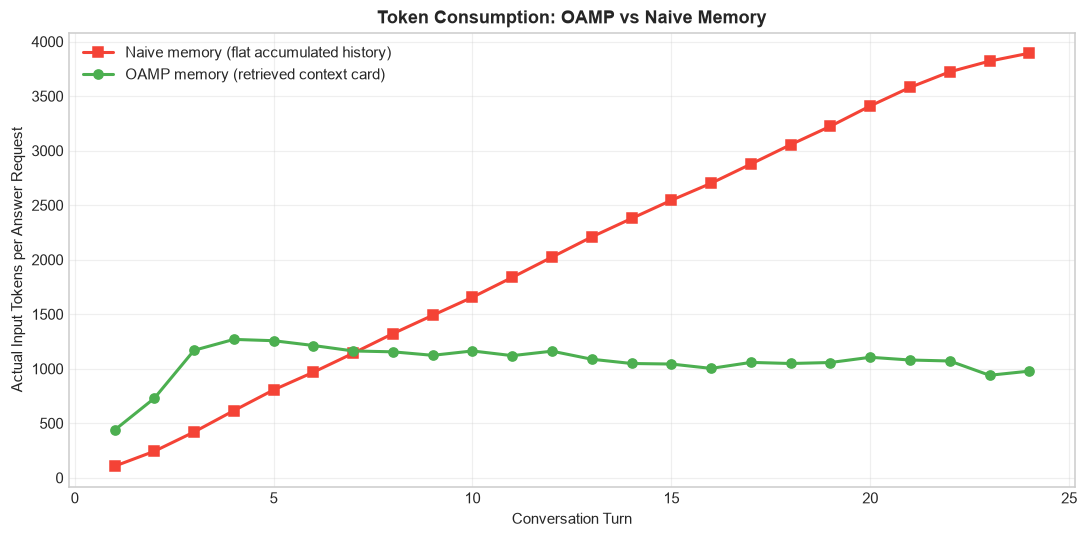


Turn     OAMP tokens    Naive tokens      Growth ratio
1                437             106              0.2x
2                729             243              0.3x
3              1,169             420              0.4x
4              1,269             616              0.5x
5              1,257             806              0.6x
6              1,213             968              0.8x
7              1,163           1,142              1.0x
8              1,155           1,322              1.1x
9              1,123           1,490              1.3x
10             1,163           1,656              1.4x
11             1,120           1,838              1.6x
12             1,161           2,024              1.7x
13             1,087           2,209              2.0x
14             1,048           2,378              2.3x
15             1,043           2,545              2.4x
16             1,003           2,701              2.7x
17             1,058           2,877              2.7x
18       

In [6]:
if "align_metric_series" not in globals():
    def align_metric_series(label: str, *series):
        lengths = [len(values) for values in series]
        if not lengths or min(lengths) == 0:
            raise RuntimeError(f"No data to plot for {label}. Run the benchmark cells that populate the metric arrays first.")
        n = min(lengths)
        if len(set(lengths)) != 1:
            print(f"[warn] {label}: aligning series to the first {n} turns; observed lengths={lengths}.")
            print("       Restart the kernel and rerun from the setup cells for a clean full comparison.")
        return list(range(1, n + 1)), [list(values)[:n] for values in series]

turns, (oamp_tokens, naive_tokens) = align_metric_series(
    "OAMP vs naive token plot",
    oamp_token_history,
    naive_token_history,
)

plt.figure(figsize=(10, 5))
plt.plot(turns, naive_tokens, marker="s", color="#F44336",
         label="Naive memory (flat accumulated history)", linewidth=2)
plt.plot(turns, oamp_tokens, marker="o", color="#4CAF50",
         label="OAMP memory (retrieved context card)", linewidth=2)
plt.xlabel("Conversation Turn")
plt.ylabel("Actual Input Tokens per Answer Request")
plt.title("Token Consumption: OAMP vs Naive Memory")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

total_naive = sum(naive_tokens)
total_oamp = sum(oamp_tokens)
savings = (1 - total_oamp / total_naive) * 100 if total_naive else 0.0

print("\n" + "=" * 60)
print(f"{'Turn':<6}{'OAMP tokens':>14}{'Naive tokens':>16}{'Growth ratio':>18}")
print("=" * 60)
for t, o, n in zip(turns, oamp_tokens, naive_tokens):
    ratio = n / o if o else float("inf")
    print(f"{t:<6}{o:>14,}{n:>16,}{ratio:>17.1f}x")
print("=" * 60)
print(f"{'TOTAL':<6}{total_oamp:>14,}{total_naive:>16,}")
print(f"\nOAMP answer prompts sent {savings:.1f}% fewer input tokens across the plotted turns.")
print(f"By turn {turns[-1]}, the naive agent is sending {naive_tokens[-1] / oamp_tokens[-1]:.1f}x "
      f"more tokens per request than the OAMP agent.")


answer_oamp_total = sum(oamp_tokens)
hotpath_oamp_total = sum(oamp_hotpath_input_history[:len(turns)])
answer_naive_total = sum(naive_tokens)
hotpath_naive_total = sum(naive_hotpath_input_history[:len(turns)])

print("\nExact provider billing boundary:")
print(f"  OAMP answer calls:           {answer_oamp_total:>9,} input tokens")
print(f"  OAMP all hot-path calls:     {hotpath_oamp_total:>9,} input tokens")
print(f"  Naive answer/hot-path calls: {hotpath_naive_total:>9,} input tokens")
print(f"  OAMP memory-maintenance tax: {hotpath_oamp_total - answer_oamp_total:>9,} input tokens")
print("The chart isolates answer-context size; the all-hot-path total is the operational-cost view.")

naive_cache_share = sum(naive_cached_token_history[:len(turns)]) / max(1, answer_naive_total)
oamp_cache_share = sum(oamp_cached_token_history[:len(turns)]) / max(1, answer_oamp_total)
print(f"Provider-reported cached share — naive: {naive_cache_share:.1%}; OAMP answer: {oamp_cache_share:.1%}")

---

## Benchmark 2 — Latency

Does OAMP's smaller answer prompt offset database retrieval and synchronous memory-maintenance overhead? Each turn records **retrieval latency** (through context-card construction) and **end-to-end latency** (query received through answer persistence).

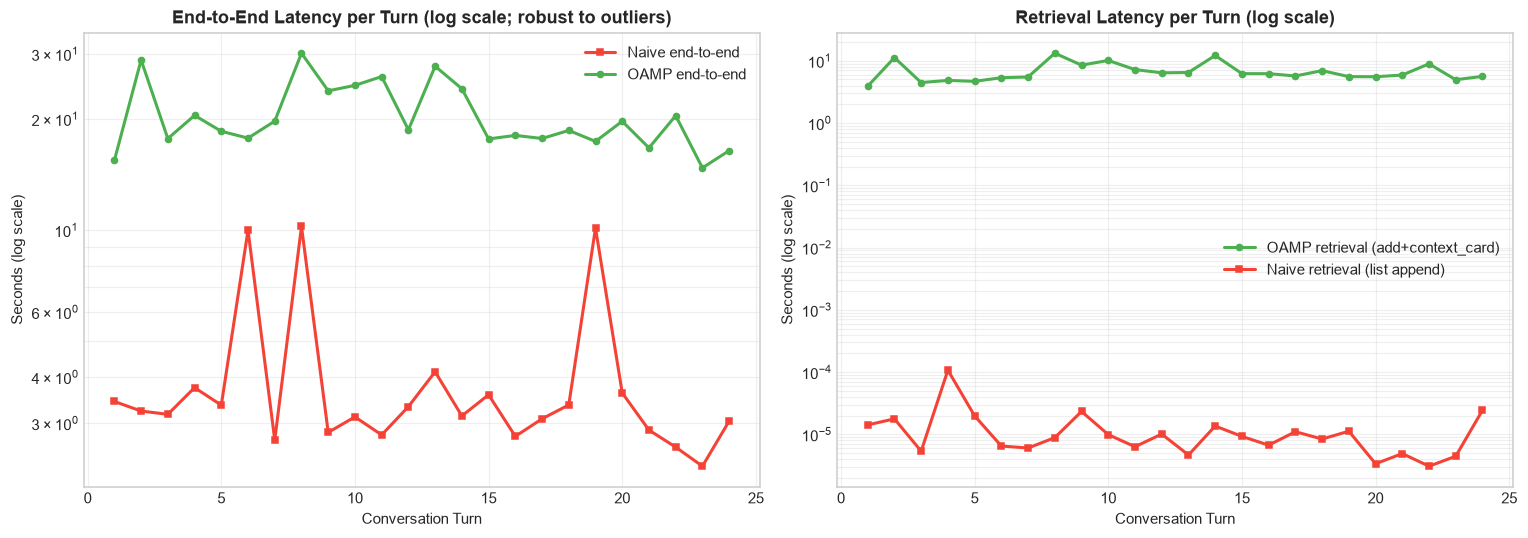


Metric                                mean         p50         p95         max       where
OAMP end-to-end (s)                 20.45s      18.64s      28.70s      30.13s      turn 8
Naive end-to-end (s)                 4.02s       3.20s      10.11s      10.23s      turn 8
OAMP retrieval (s)                   6.89s       6.04s      12.01s      13.23s      turn 8
Naive retrieval (s)                  0.00s       0.00s       0.00s       0.00s      turn 4

Mean is sensitive to tail-latency outliers; p50 (median) and p95 give a more honest view of typical performance.


In [7]:
if "align_metric_series" not in globals():
    def align_metric_series(label: str, *series):
        lengths = [len(values) for values in series]
        if not lengths or min(lengths) == 0:
            raise RuntimeError(f"No data to plot for {label}. Run the benchmark cells that populate the metric arrays first.")
        n = min(lengths)
        if len(set(lengths)) != 1:
            print(f"[warn] {label}: aligning series to the first {n} turns; observed lengths={lengths}.")
            print("       Restart the kernel and rerun from the setup cells for a clean full comparison.")
        return list(range(1, n + 1)), [list(values)[:n] for values in series]

import numpy as np

turns, (oamp_total, naive_total, oamp_retrieval, naive_retrieval) = align_metric_series(
    "OAMP vs naive latency plot",
    oamp_total_latency,
    naive_total_latency,
    oamp_retrieval_latency,
    naive_retrieval_latency,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(turns, naive_total, marker="s", color="#F44336",
         label="Naive end-to-end", linewidth=2, markersize=4)
ax1.plot(turns, oamp_total, marker="o", color="#4CAF50",
         label="OAMP end-to-end", linewidth=2, markersize=4)
ax1.set_xlabel("Conversation Turn")
ax1.set_ylabel("Seconds (log scale)")
ax1.set_title("End-to-End Latency per Turn (log scale; robust to outliers)")
ax1.set_yscale("log")
ax1.grid(True, alpha=0.3, which="both")
ax1.legend()

ax2.plot(turns, oamp_retrieval, marker="o", color="#4CAF50",
         label="OAMP retrieval (add+context_card)", linewidth=2, markersize=4)
ax2.plot(turns, naive_retrieval, marker="s", color="#F44336",
         label="Naive retrieval (list append)", linewidth=2, markersize=4)
ax2.set_xlabel("Conversation Turn")
ax2.set_ylabel("Seconds (log scale)")
ax2.set_title("Retrieval Latency per Turn (log scale)")
ax2.set_yscale("log")
ax2.grid(True, alpha=0.3, which="both")
ax2.legend()

plt.tight_layout()
plt.show()


def _pcts(arr):
    a = np.asarray(arr, dtype=float)
    return float(np.mean(a)), float(np.median(a)), float(np.percentile(a, 95)), float(np.max(a))


print("\n" + "=" * 90)
print(f"{'Metric':<30}{'mean':>12}{'p50':>12}{'p95':>12}{'max':>12}{'where':>12}")
print("=" * 90)

for label, arr in [
    ("OAMP end-to-end (s)", oamp_total),
    ("Naive end-to-end (s)", naive_total),
    ("OAMP retrieval (s)", oamp_retrieval),
    ("Naive retrieval (s)", naive_retrieval),
]:
    mean, p50, p95, mx = _pcts(arr)
    where = int(np.argmax(arr)) + 1
    print(f"{label:<30}{mean:>11.2f}s{p50:>11.2f}s{p95:>11.2f}s{mx:>11.2f}s{('turn ' + str(where)):>12}")

print("=" * 90)
print("\nMean is sensitive to tail-latency outliers; p50 (median) and p95 give a more honest view of typical performance.")


> **How should these latency results be read?**
>
> OpenAI automatically caches sufficiently long repeated prompt prefixes, and the API reports the cached portion in `input_tokens_details.cached_tokens`. The naive and cache-friendly histories are append-only, so they can reuse a stable prefix. The basic OAMP prompt rebuilds a changing context card and therefore has a less stable prefix.
>
> Basic OAMP also performs extraction and context-summary work synchronously because `extract_memories=True`. Those GPT-5.5 calls are part of its observed end-to-end time and are explicitly included in `oamp_hotpath_input_history`.
>
> Use **p50** for typical latency and **p95** for tail behavior; the mean is easily distorted by one retry or long generation. A local Oracle Database also differs from a production network topology, so treat these values as measurements of this run—not universal service guarantees.
>
> Production options include lowering extraction frequency, using a smaller extraction model, moving extraction off the request path, and preserving a byte-stable prompt prefix. The cache-friendly pattern below demonstrates the last two.

---

## Benchmark 3 — Context-grounded response quality

The naive agent sees verbatim history; basic OAMP sees a retrieved context card. A GPT-5.5 judge compares the responses using the scripted conversation up to that turn as reference evidence.

Two safeguards improve on the source evaluation:

1. OAMP alternates between positions A and B, reducing simple first-position bias.
2. The judge receives the preceding scripted facts, so “accuracy” is grounded rather than guessed from the current question alone.

This remains an **LLM-as-a-judge proxy**, not human ground truth. Because GPT-5.5 is also the response model, possible self-preference is a stated limitation. Production evaluation should add blinded human review and task-specific deterministic assertions.

In [8]:
import json as _json_lib

JUDGE_SCHEMA = {
    "type": "object",
    "properties": {
        "winner": {"type": "string", "enum": ["A", "B", "Tie"]},
        "reason": {"type": "string"},
    },
    "required": ["winner", "reason"],
    "additionalProperties": False,
}

JUDGE_PROMPT = """You are evaluating two assistant responses.

REFERENCE CONVERSATION THROUGH THIS TURN:
{reference_context}

CURRENT USER TURN:
{query}

RESPONSE A:
{response_a}

RESPONSE B:
{response_b}

Compare factual accuracy against the reference conversation, completeness, relevance, and clarity.
Do not prefer a response merely because it is longer. Return the requested JSON only."""


def judge_turn(
    reference_context: str,
    query: str,
    response_a: str,
    response_b: str,
) -> dict[str, str]:
    raw = call_chat(
        [{
            "role": "user",
            "content": JUDGE_PROMPT.format(
                reference_context=reference_context,
                query=query,
                response_a=response_a,
                response_b=response_b,
            ),
        }],
        temperature=0.0,
        max_tokens=700,
        response_json_schema=JUDGE_SCHEMA,
        purpose="quality_judge",
    ).strip()
    return _json_lib.loads(raw)


judgments = []
print(f"Judging {len(conversation_turns)} turn-pairs with {OPENAI_MODEL}...\n")
for i, (q, oamp_answer, naive_answer) in enumerate(
    zip(conversation_turns, oamp_responses, naive_responses), 1
):
    reference_context = "\n".join(
        f"Turn {turn_number}: {turn_text}"
        for turn_number, turn_text in enumerate(conversation_turns[:i], 1)
    )
    oamp_is_a = i % 2 == 1
    response_a = oamp_answer if oamp_is_a else naive_answer
    response_b = naive_answer if oamp_is_a else oamp_answer
    verdict = judge_turn(reference_context, q, response_a, response_b)
    raw_winner = verdict["winner"]
    if raw_winner == "Tie":
        winner_system = "Tie"
    elif (raw_winner == "A") == oamp_is_a:
        winner_system = "OAMP"
    else:
        winner_system = "Naive"
    verdict.update(
        query=q,
        oamp_position="A" if oamp_is_a else "B",
        winner_system=winner_system,
    )
    judgments.append(verdict)
    print(
        f"Turn {i:2d}: OAMP={verdict['oamp_position']} winner={winner_system:<5} "
        f"{verdict['reason'][:100]}"
    )

Judging 24 turn-pairs with gpt-5.5...



Turn  1: OAMP=A winner=OAMP  Both responses are accurate, relevant, and clear, and neither introduces problematic unsupported det


Turn  2: OAMP=B winner=OAMP  Both responses are factually consistent with the reference and relevant to the repeated project desc


Turn  3: OAMP=A winner=Naive Both responses are factually consistent with the reference and relevant. Response B is slightly bett


Turn  4: OAMP=B winner=OAMP  Both responses are factually consistent with the reference and relevant to the repeated project desc


...

Turn 20: OAMP=B winner=OAMP  Both responses accurately capture the funding stack and Dr. Kemi Okafor’s role. Response B is slight


Turn 21: OAMP=A winner=Naive Both responses accurately capture the stated constraint and are clear and relevant. Response A is a 


Turn 22: OAMP=B winner=OAMP  Both responses are factually accurate, complete, relevant, and clear. Response B is slightly better 


Turn 23: OAMP=A winner=Tie   Both responses accurately recall the cohort size as 3,412 trios and identify the two primary sequenc


Turn 24: OAMP=B winner=Naive Both responses are factually accurate, relevant, and clear. Response B is concise and captures the m


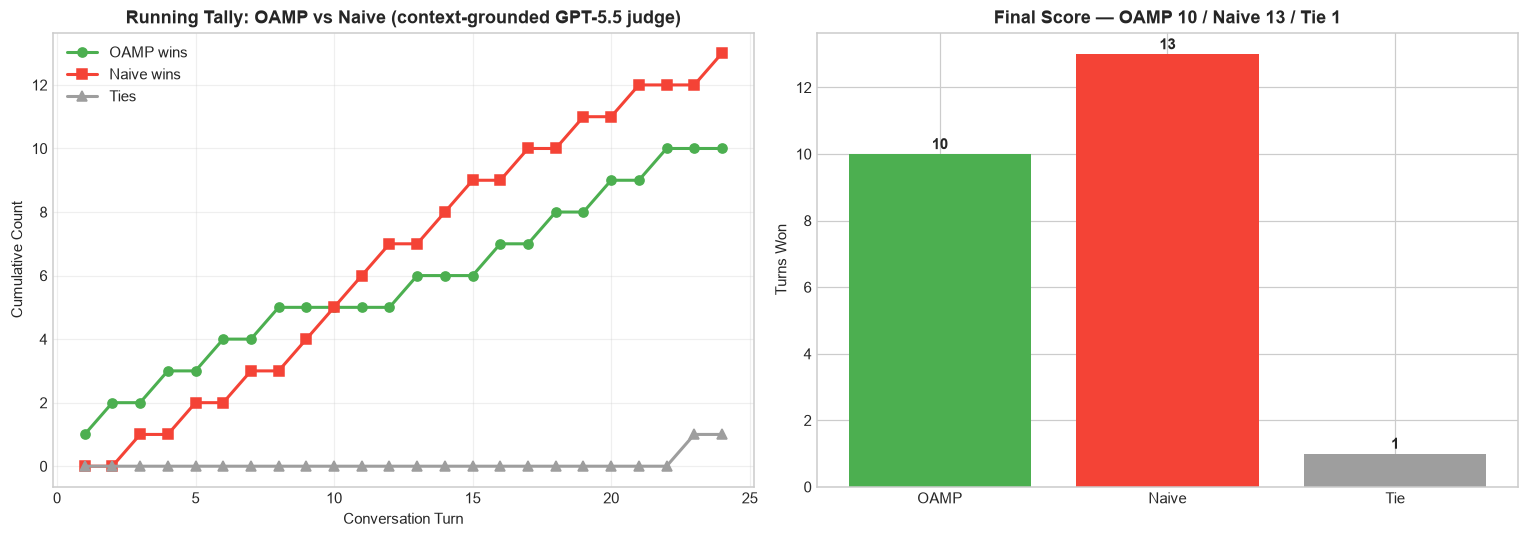


=== Final tally over 24 turns ===
  OAMP  wins:  10 ( 41.7%)
  Naive wins:  13 ( 54.2%)
  Ties:         1 (  4.2%)


In [9]:
wins = {"OAMP": 0, "Naive": 0, "Tie": 0}
oamp_running, naive_running, tie_running = [], [], []

for j in judgments:
    wins[j["winner_system"]] += 1
    oamp_running.append(wins["OAMP"])
    naive_running.append(wins["Naive"])
    tie_running.append(wins["Tie"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Running cumulative wins
turns = list(range(1, len(judgments) + 1))
ax1.plot(turns, oamp_running,  marker="o", color="#4CAF50", label="OAMP wins",  linewidth=2)
ax1.plot(turns, naive_running, marker="s", color="#F44336", label="Naive wins", linewidth=2)
ax1.plot(turns, tie_running,   marker="^", color="#9E9E9E", label="Ties",       linewidth=2)
ax1.set_xlabel("Conversation Turn")
ax1.set_ylabel("Cumulative Count")
ax1.set_title("Running Tally: OAMP vs Naive (context-grounded GPT-5.5 judge)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Final bar chart
colors = {"OAMP": "#4CAF50", "Naive": "#F44336", "Tie": "#9E9E9E"}
bars = ax2.bar(list(wins.keys()), list(wins.values()), color=[colors[k] for k in wins])
ax2.set_ylabel("Turns Won")
ax2.set_title(f"Final Score — OAMP {wins['OAMP']} / Naive {wins['Naive']} / Tie {wins['Tie']}")
for bar, count in zip(bars, wins.values()):
    if count > 0:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 str(count), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

total = len(judgments)
print(f"\n=== Final tally over {total} turns ===")
print(f"  OAMP  wins: {wins['OAMP']:3d} ({wins['OAMP']/total*100:5.1f}%)")
print(f"  Naive wins: {wins['Naive']:3d} ({wins['Naive']/total*100:5.1f}%)")
print(f"  Ties:       {wins['Tie']:3d} ({wins['Tie']/total*100:5.1f}%)")


---

## Benchmark 4 — Cache-friendly OAMP agent

The first two patterns expose a trade-off:

| Agent | Answer-context tokens | Hot-path work | Cross-session memory |
|---|---|---|---|
| Naive | grows linearly | one answer call | none |
| OAMP basic | compact context card | answer + synchronous extraction/summary | yes |

The third pattern mirrors an append-only prompt history into Oracle, searches durable memory into only the newest tail, disables synchronous extraction, and compacts old turns every 20 turns. It aims for durable memory and a stable cacheable prefix without hiding maintenance work.

### Implementation choices

| Choice | Implementation | Consequence |
|---|---|---|
| Stable prefix | append to `cached_messages`; memory hints go in the newest user turn | earlier prompt bytes can be cached |
| Mirrored durability | persist each turn to `cached_thread` | the database survives process and session loss |
| Off-path extraction | `extract_memories=False`; one batch extraction after the run | no extraction model call in the answer path |
| Scheduled compaction | summarize old history every 20 turns, keep four recent turns | token growth becomes a sawtooth; the boundary resets the prompt prefix |

Provider-reported cached tokens are recorded, so this notebook tests cache behavior rather than inferring it from a flat latency line.

In [10]:
cached_connection = oracledb.connect(
    user=os.environ["DB_USER"],
    password=DB_PASSWORD,
    dsn=os.environ["DB_CONNECT_STRING"],
)

cached_client = OracleAgentMemory(
    connection=cached_connection,
    embedder=oamp_embedder,
    extract_memories=False,
    schema_policy="create_if_necessary",
    table_name_prefix="OAMPG55",
)

CACHED_USER = "benchmark-user-cached-openai"
CACHED_AGENT = "benchmark-agent-cached-openai"

for fn, eid, info in [
    (cached_client.add_user, CACHED_USER, "Richmond - cache-friendly GPT-5.5 benchmark."),
    (cached_client.add_agent, CACHED_AGENT, "Cache-friendly OAMP-backed GPT-5.5 assistant."),
]:
    try:
        fn(eid, info)
    except ValueError as exc:
        if "already exists" not in str(exc):
            raise

cached_thread = cached_client.create_thread(user_id=CACHED_USER, agent_id=CACHED_AGENT)

cached_token_history = []
cached_cached_token_history = []
cached_hotpath_input_history = []
cached_retrieval_latency = []
cached_total_latency = []
cached_responses = []
cached_messages = [{"role": "system", "content": SYSTEM_PROMPT}]
compaction_events = []

COMPACTION_INTERVAL = 20
KEEP_RECENT_TURNS = 4


def call_oamp_cached_agent(user_query: str) -> str:
    """Append-only prompt history, Oracle memory search, and mirrored persistence."""
    call_start = len(OPENAI_CALL_LOG)
    t_start = time.perf_counter()
    t_retrieve_start = time.perf_counter()
    hits = cached_client.search(
        user_query,
        user_id=CACHED_USER,
        agent_id=CACHED_AGENT,
        max_results=3,
        record_types=["memory"],
    )
    hint = (
        "\n\n[Memory hints from prior sessions:\n"
        + "\n".join(f"- {hit.content}" for hit in hits)
        + "]"
        if hits
        else ""
    )
    t_retrieve_end = time.perf_counter()

    cached_messages.append({"role": "user", "content": user_query + hint})
    answer = call_chat(
        cached_messages,
        purpose="cached_answer",
        prompt_cache_key="memory-benchmark-cached",
    )
    cached_messages.append({"role": "assistant", "content": str(answer)})
    cached_thread.add_messages([
        Message(role="user", content=user_query),
        Message(role="assistant", content=str(answer)),
    ])

    t_end = time.perf_counter()
    turn_calls = OPENAI_CALL_LOG[call_start:]
    cached_token_history.append(answer.usage["input_tokens"])
    cached_cached_token_history.append(answer.usage["cached_tokens"])
    cached_hotpath_input_history.append(usage_sum(turn_calls, "input_tokens"))
    cached_retrieval_latency.append(t_retrieve_end - t_retrieve_start)
    cached_total_latency.append(t_end - t_start)
    cached_responses.append(str(answer))
    return str(answer)


def compact_older_messages(turn_number: int) -> bool:
    """Replace older messages with a GPT-5.5 summary on scheduled boundaries."""
    if turn_number == 0 or turn_number % COMPACTION_INTERVAL != 0:
        return False

    keep_msg_count = 2 * KEEP_RECENT_TURNS
    if len(cached_messages) <= 1 + keep_msg_count + 2:
        return False

    older = cached_messages[1:-keep_msg_count]
    recent = cached_messages[-keep_msg_count:]
    if not older:
        return False

    transcript = "\n".join(f"[{m['role']}] {m['content']}" for m in older)
    summary = call_chat(
        [{
            "role": "user",
            "content": (
                "Condense this conversation history. Preserve every named entity, number, date, "
                "decision, method, patient case identifier, and personnel change. Aim for 30-40% "
                f"of the original length.\n\nTranscript:\n{transcript}"
            ),
        }],
        temperature=0.1,
        max_tokens=2000,
        purpose="cached_compaction",
    )
    cached_messages[:] = (
        [cached_messages[0]]
        + [{
            "role": "system",
            "content": (
                f"[Earlier conversation summary through turn "
                f"{turn_number - KEEP_RECENT_TURNS}]\n{summary}"
            ),
        }]
        + recent
    )
    compaction_events.append(
        {
            "turn": turn_number,
            "input_tokens": summary.usage["input_tokens"],
            "output_tokens": summary.usage["output_tokens"],
        }
    )
    return True


print("Cache-friendly OAMP agent ready.")
print(f"Compaction every {COMPACTION_INTERVAL} turns; keeping {KEEP_RECENT_TURNS} turns verbatim.")

/var/folders/q5/mqxgw8bd5t3b68thxd06mpnm0000gn/T/ipykernel_51997/557379733.py:7: DeprecationWarning: Inline memory extraction parameters are deprecated for OracleAgentMemory(). Use:
from oracleagentmemory.core import MemoryExtractionConfig
memory_extraction_config=MemoryExtractionConfig(extract_memories=...)
  cached_client = OracleAgentMemory(
/var/folders/q5/mqxgw8bd5t3b68thxd06mpnm0000gn/T/ipykernel_51997/557379733.py:7: DeprecationWarning: table_name_prefix is deprecated and will be removed in 27.1; use memory_store_id instead.
  cached_client = OracleAgentMemory(


Cache-friendly OAMP agent ready.
Compaction every 20 turns; keeping 4 turns verbatim.


### Why this design

`extract_memories=False` makes `cached_thread.add_messages(...)` a database persistence operation rather than a synchronous LLM-maintenance step. Retrieval still queries Oracle, but any hits are appended to the newest user message; earlier prompt bytes remain unchanged.

The in-memory list and Oracle thread deliberately serve different purposes:

- `cached_messages` is the low-latency prompt source for the current process.
- `cached_thread` is the durable, scoped record that can be reopened by another process.
- The offline extraction section turns the persisted transcript into cross-thread searchable memories after the user-facing work finishes.

Compaction is separately logged because it is scheduled maintenance, not part of the turn-20 answer latency.

### Run the same turns through the cache-friendly agent

The identical truncated workload is replayed. Answer input tokens, provider cache hits, vector-search latency, total latency, and scheduled compaction usage are all captured.

In [11]:
print(f"Running {len(conversation_turns)} turns through the cache-friendly OAMP agent...\n")
for i, q in enumerate(conversation_turns, 1):
    print(f"=== Turn {i:2d}/{len(conversation_turns)} ===")
    print(f"USER: {q[:140]}{'...' if len(q) > 140 else ''}")
    answer = call_oamp_cached_agent(q)
    print(
        f"  [Cached, input={cached_token_history[-1]:>5}, "
        f"cache-hit={cached_cached_token_history[-1]:>5}, "
        f"{cached_total_latency[-1]:5.1f}s] {answer[:120]}"
    )
    if compact_older_messages(i):
        event = compaction_events[-1]
        print(
            f"  [Compacted at turn {i}: {event['input_tokens']} input + "
            f"{event['output_tokens']} output tokens; next answer starts a new prefix]"
        )
    print()

Running 24 turns through the cache-friendly OAMP agent...

=== Turn  1/24 ===
USER: Hi! I'm Dr. Richmond Alake, a senior computational genomics researcher at the Oracle Life Sciences Institute. I lead a team of eight bioinfo...


oracleagentmemory/core/oracleagentmemory.py:2029: UserWarning: You are calling an asynchronous method in a synchronous method from an asynchronous context. This is highly discouraged because it can lead to deadlocks. Please use the asynchronous method equivalent: 


  [Cached, input=  106, cache-hit=    0,   3.0s] Hello Dr. Alake—nice to meet you. I can help with literature synthesis, variant prioritization strategies, regulatory ge

=== Turn  2/24 ===
USER: The specific project I want help with is called ChromAtlas-ND. We are building a whole-genome variant annotation pipeline that integrates lo...


  [Cached, input=  243, cache-hit=    0,   4.1s] ChromAtlas-ND sounds like a strong multi-omic WGS interpretation effort: long reads can resolve SV structure/phasing whi

=== Turn  3/24 ===
USER: My principal wet-lab collaborator is Dr. Sarah Chen at Baylor College of Medicine in Houston. Sarah runs the single-cell ATAC-seq and Hi-C a...


  [Cached, input=  430, cache-hit=    0,   4.2s] Great—Dr. Chen’s matched 10x Multiome and Hi-C/organoid expertise can provide the functional regulatory context needed t

=== Turn  4/24 ===
USER: On the computational side, we are comparing three variant-prioritization strategies. The first is a pure sequence-based approach using Enfor...


...

  [Compacted at turn 20: 2835 input + 1294 output tokens; next answer starts a new prefix]

=== Turn 21/24 ===
USER: An important constraint to remember: all raw sequencing data for the clinical validation cohort must remain inside the HIPAA-audited Oracle ...


  [Cached, input= 2070, cache-hit=    0,   3.3s] Understood: raw clinical-validation sequencing data is restricted to the HIPAA-audited Oracle Cloud Ashburn enclave, wit

=== Turn 22/24 ===
USER: One more operational detail: we hold a project-wide sync every Tuesday at 10am Central, with a monthly external steering committee review on...


  [Cached, input= 2221, cache-hit= 1792,   4.8s] Noted: weekly project-wide syncs are Tuesdays at 10am Central, and external steering reviews occur the first Friday mont

=== Turn 23/24 ===
USER: Recall check 1 — what is the cohort size for ChromAtlas-ND, and which two sequencing platforms are we using for the primary variant calls?


  [Cached, input= 2334, cache-hit= 1792,   2.3s] ChromAtlas-ND includes **3,412 trios**. The primary variant calls integrate long-read **Oxford Nanopore PromethION** and

=== Turn 24/24 ===
USER: Recall check 2 — please list my three main collaborators, their institutions, and what arm of the project each one leads.


  [Cached, input= 2411, cache-hit= 1792,   4.1s] Your three main collaborators are: **Dr. Sarah Chen** at **Baylor College of Medicine / Jan and Dan Duncan Neurological 



### Compare all three patterns on answer-context tokens

The chart uses exact input tokens for each **answer call**. The basic OAMP context card should remain relatively compact; naive and cache-friendly histories grow until compaction. Scheduled compaction tokens and OAMP's synchronous memory-maintenance tokens are reported separately rather than mixed into answer-context size.

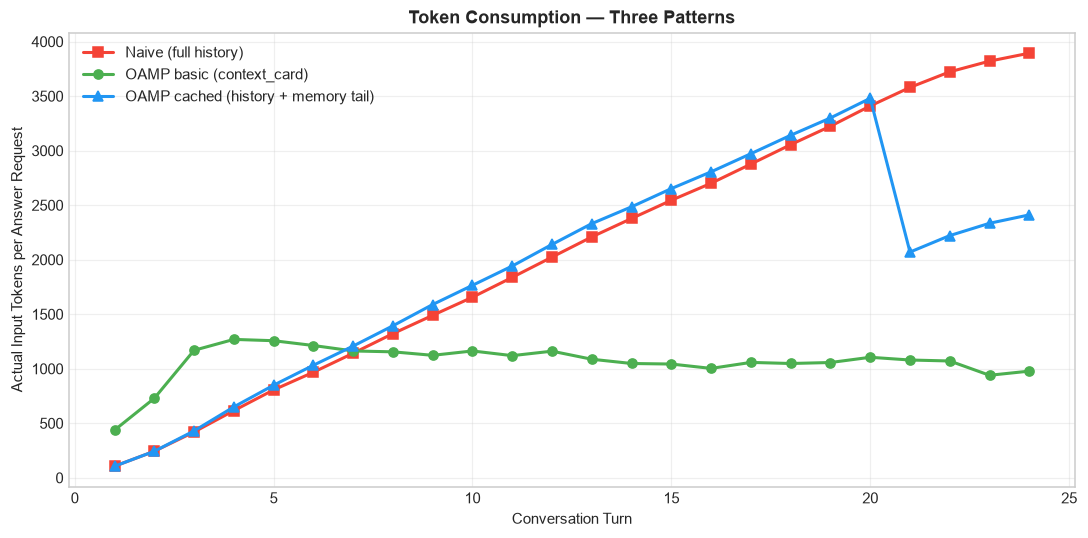


Final plotted-turn input tokens:
  Naive:        3,894
  OAMP basic:     978
  OAMP cached:  2,411

Provider-reported prompt-cache usage across answer calls:
  Naive          24,832 /   50,048 input tokens cached (49.6%)
  OAMP basic          0 /   25,477 input tokens cached (0.0%)
  OAMP cached    22,784 /   45,551 input tokens cached (50.0%)

Scheduled compaction usage (outside answer latency):
  turn 20: 2,835 input + 1,294 output tokens


In [12]:
if "align_metric_series" not in globals():
    def align_metric_series(label: str, *series):
        lengths = [len(values) for values in series]
        if not lengths or min(lengths) == 0:
            raise RuntimeError(f"No data to plot for {label}. Run the benchmark cells that populate the metric arrays first.")
        n = min(lengths)
        if len(set(lengths)) != 1:
            print(f"[warn] {label}: aligning series to the first {n} turns; observed lengths={lengths}.")
            print("       Restart the kernel and rerun from the setup cells for a clean full comparison.")
        return list(range(1, n + 1)), [list(values)[:n] for values in series]

turns, (naive_tokens, oamp_tokens, cached_tokens) = align_metric_series(
    "three-pattern token plot",
    naive_token_history,
    oamp_token_history,
    cached_token_history,
)

plt.figure(figsize=(10, 5))
plt.plot(turns, naive_tokens, marker="s", color="#F44336", linewidth=2, label="Naive (full history)")
plt.plot(turns, oamp_tokens, marker="o", color="#4CAF50", linewidth=2, label="OAMP basic (context_card)")
plt.plot(turns, cached_tokens, marker="^", color="#2196F3", linewidth=2, label="OAMP cached (history + memory tail)")
plt.xlabel("Conversation Turn")
plt.ylabel("Actual Input Tokens per Answer Request")
plt.title("Token Consumption — Three Patterns")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nFinal plotted-turn input tokens:")
print(f"  Naive:       {naive_tokens[-1]:>6,}")
print(f"  OAMP basic:  {oamp_tokens[-1]:>6,}")
print(f"  OAMP cached: {cached_tokens[-1]:>6,}")

print("\nProvider-reported prompt-cache usage across answer calls:")
for label, inputs, cached in [
    ("Naive", naive_token_history, naive_cached_token_history),
    ("OAMP basic", oamp_token_history, oamp_cached_token_history),
    ("OAMP cached", cached_token_history, cached_cached_token_history),
]:
    share = sum(cached) / max(1, sum(inputs))
    print(f"  {label:<12} {sum(cached):>8,} / {sum(inputs):>8,} input tokens cached ({share:.1%})")

print("\nScheduled compaction usage (outside answer latency):")
if compaction_events:
    for event in compaction_events:
        print(f"  turn {event['turn']}: {event['input_tokens']:,} input + {event['output_tokens']:,} output tokens")
else:
    print("  no compaction boundary reached in this run")


> **Why can naive and cache-friendly answer-token curves look similar?**
>
> They intentionally share an append-only history. Cache-friendly OAMP adds durable Oracle persistence, scoped vector search, cross-session recall, auditability, and scheduled compaction. Those properties are absent from a process-local Python list.
>
> Basic OAMP optimizes answer-context size with a context card but performs synchronous memory work in this configuration. Cache-friendly OAMP optimizes user-perceived latency by moving extraction off the answer path. There is no universal winner: compare the exact answer tokens, all-hot-path tokens, cache hits, p50/p95 latency, recall quality, and durability required by your application.

### Compare all three patterns on latency

Naive and cache-friendly agents each make one user-facing model call per ordinary turn. Basic OAMP additionally runs synchronous memory extraction and summary maintenance. The log-scale charts and percentile table preserve the source benchmark's latency evaluation while making that work boundary explicit.

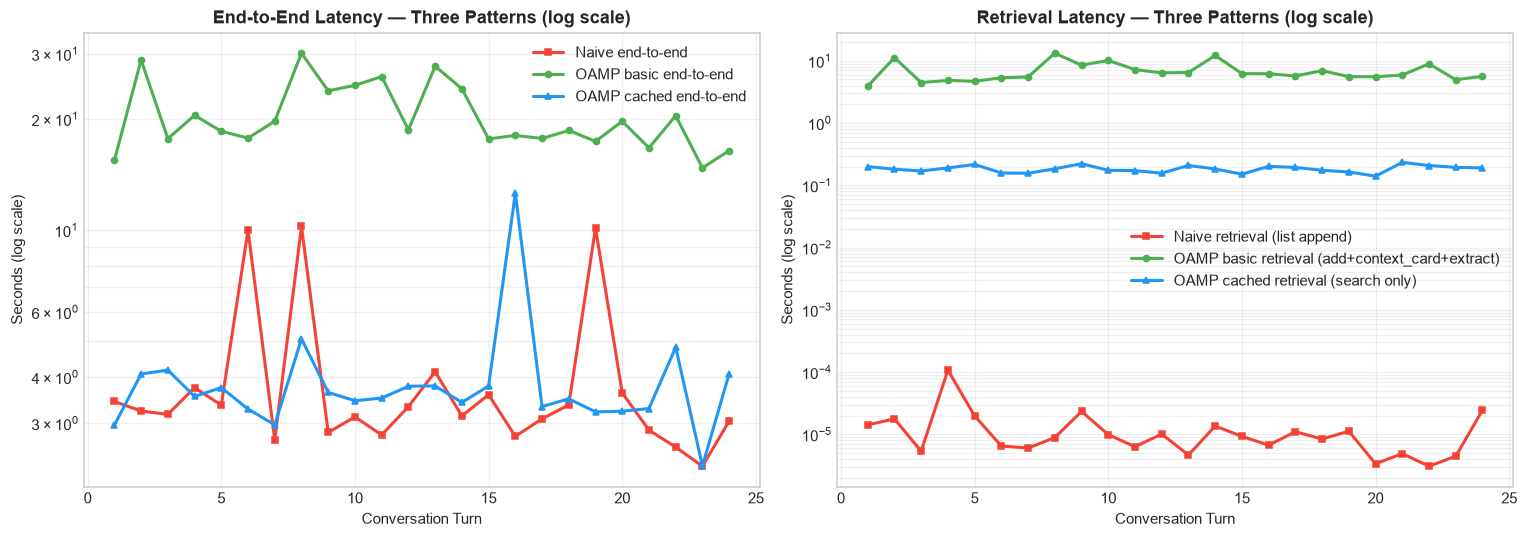


Metric                                 pattern      mean       p50       p95       max      max@turn
End-to-end per turn (s)                  Naive     4.02s     3.20s    10.11s    10.23s        turn 8
End-to-end per turn (s)             OAMP basic    20.45s    18.64s    28.70s    30.13s        turn 8
End-to-end per turn (s)            OAMP cached     3.98s     3.53s     5.03s    12.57s       turn 16
Retrieval per turn (s)                   Naive     0.00s     0.00s     0.00s     0.00s        turn 4
Retrieval per turn (s)              OAMP basic     6.89s     6.04s    12.01s    13.23s        turn 8
Retrieval per turn (s)             OAMP cached     0.18s     0.18s     0.22s     0.23s       turn 21

Total wall-clock time across the plotted turns:
  Naive:          96.5s
  OAMP basic:    490.9s   (sum is sensitive to tail-latency outliers)
  OAMP cached:    95.5s


In [13]:
if "align_metric_series" not in globals():
    def align_metric_series(label: str, *series):
        lengths = [len(values) for values in series]
        if not lengths or min(lengths) == 0:
            raise RuntimeError(f"No data to plot for {label}. Run the benchmark cells that populate the metric arrays first.")
        n = min(lengths)
        if len(set(lengths)) != 1:
            print(f"[warn] {label}: aligning series to the first {n} turns; observed lengths={lengths}.")
            print("       Restart the kernel and rerun from the setup cells for a clean full comparison.")
        return list(range(1, n + 1)), [list(values)[:n] for values in series]

turns, (
    naive_total,
    oamp_total,
    cached_total,
    naive_retrieval,
    oamp_retrieval,
    cached_retrieval,
) = align_metric_series(
    "three-pattern latency plot",
    naive_total_latency,
    oamp_total_latency,
    cached_total_latency,
    naive_retrieval_latency,
    oamp_retrieval_latency,
    cached_retrieval_latency,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(turns, naive_total, marker="s", color="#F44336", linewidth=2, markersize=4, label="Naive end-to-end")
ax1.plot(turns, oamp_total, marker="o", color="#4CAF50", linewidth=2, markersize=4, label="OAMP basic end-to-end")
ax1.plot(turns, cached_total, marker="^", color="#2196F3", linewidth=2, markersize=4, label="OAMP cached end-to-end")
ax1.set_xlabel("Conversation Turn")
ax1.set_ylabel("Seconds (log scale)")
ax1.set_title("End-to-End Latency — Three Patterns (log scale)")
ax1.set_yscale("log")
ax1.grid(True, alpha=0.3, which="both")
ax1.legend()

ax2.plot(turns, naive_retrieval, marker="s", color="#F44336", linewidth=2, markersize=4, label="Naive retrieval (list append)")
ax2.plot(turns, oamp_retrieval, marker="o", color="#4CAF50", linewidth=2, markersize=4, label="OAMP basic retrieval (add+context_card+extract)")
ax2.plot(turns, cached_retrieval, marker="^", color="#2196F3", linewidth=2, markersize=4, label="OAMP cached retrieval (search only)")
ax2.set_xlabel("Conversation Turn")
ax2.set_ylabel("Seconds (log scale)")
ax2.set_title("Retrieval Latency — Three Patterns (log scale)")
ax2.set_yscale("log")
ax2.grid(True, alpha=0.3, which="both")
ax2.legend()

plt.tight_layout()
plt.show()


def _pcts3(arr):
    a = np.asarray(arr, dtype=float)
    return (float(np.mean(a)),
            float(np.median(a)),
            float(np.percentile(a, 95)),
            float(np.max(a)),
            int(np.argmax(a)) + 1)


print("\n" + "=" * 110)
print(f"{'Metric':<32}{'pattern':>14}{'mean':>10}{'p50':>10}{'p95':>10}{'max':>10}{'max@turn':>14}")
print("=" * 110)

rows = [
    ("End-to-end per turn (s)", "Naive", naive_total),
    ("End-to-end per turn (s)", "OAMP basic", oamp_total),
    ("End-to-end per turn (s)", "OAMP cached", cached_total),
    ("Retrieval per turn (s)", "Naive", naive_retrieval),
    ("Retrieval per turn (s)", "OAMP basic", oamp_retrieval),
    ("Retrieval per turn (s)", "OAMP cached", cached_retrieval),
]
for label, pattern, arr in rows:
    mean, p50, p95, mx, where = _pcts3(arr)
    print(f"{label:<32}{pattern:>14}{mean:>9.2f}s{p50:>9.2f}s{p95:>9.2f}s{mx:>9.2f}s{('turn ' + str(where)):>14}")

print("=" * 110)
print()
print("Total wall-clock time across the plotted turns:")
print(f"  Naive:       {sum(naive_total):>7.1f}s")
print(f"  OAMP basic:  {sum(oamp_total):>7.1f}s   (sum is sensitive to tail-latency outliers)")
print(f"  OAMP cached: {sum(cached_total):>7.1f}s")


> **Reading the latency chart**
>
> - **Retrieval** is not the same operation for every pattern: list append for naive, Oracle search for cache-friendly OAMP, and message ingestion plus context-card construction for basic OAMP.
> - **End-to-end** includes the answer model and persistence. For basic OAMP it also includes synchronous extraction/summary work.
> - The y-axis is logarithmic. Read p50 and p95 alongside the chart, and do not generalize one laptop/database/API run into an infrastructure guarantee.
> - Prompt caching is evidenced by `cached_tokens`, not inferred solely from latency.

### Offline batch extraction

After user-facing work completes, one structured GPT-5.5 call extracts atomic durable facts from the Oracle-persisted transcript. Each fact is then embedded through OpenAI and written back to Oracle Agent Memory, making it searchable in a future thread without adding extraction latency to each chat turn.

In [14]:
print("Running offline batch extraction...")
t_extract_start = time.perf_counter()

all_messages = cached_thread.get_messages()
transcript = "\n".join(f"[{message.role}] {message.content}" for message in all_messages)

FACTS_SCHEMA = {
    "type": "object",
    "properties": {
        "facts": {
            "type": "array",
            "items": {"type": "string"},
        }
    },
    "required": ["facts"],
    "additionalProperties": False,
}
extract_prompt = f"""Extract durable, atomic facts from this conversation.
Each fact must be self-contained and useful in a future session. Preserve names,
numbers, dates, tools, case identifiers, and decisions.

Conversation transcript:
{transcript}
"""

raw_facts = call_chat(
    [{"role": "user", "content": extract_prompt}],
    temperature=0.0,
    max_tokens=3000,
    response_json_schema=FACTS_SCHEMA,
    purpose="offline_fact_extraction",
)
facts = _json_lib.loads(raw_facts)["facts"]

for fact in facts:
    cached_client.add_memory(
        fact,
        user_id=CACHED_USER,
        agent_id=CACHED_AGENT,
        thread_id=cached_thread.thread_id,
    )

t_extract_end = time.perf_counter()
verification_hits = cached_client.search(
    "project collaborators, variants, funding, and milestones",
    user_id=CACHED_USER,
    agent_id=CACHED_AGENT,
    max_results=5,
    record_types=["memory"],
)

print(f"Extracted and stored {len(facts)} durable facts in {t_extract_end - t_extract_start:.1f}s.")
print(f"A fresh Oracle vector search returned {len(verification_hits)} memories.")
print("First 5 extracted facts:")
for fact in facts[:5]:
    print(f"  - {fact}")

Running offline batch extraction...


Extracted and stored 111 durable facts in 54.1s.
A fresh Oracle vector search returned 5 memories.
First 5 extracted facts:
  - Dr. Richmond Alake is a senior computational genomics researcher at the Oracle Life Sciences Institute.
  - Dr. Richmond Alake leads a team of eight bioinformaticians investigating non-coding regulatory variants in rare pediatric neurodevelopmental disorders.
  - Dr. Richmond Alake's cohort is mostly from the GeneDx Trio Consortium.
  - Dr. Richmond Alake's grant is funded by the NIH Common Fund's 4D Nucleome program through 2028.
  - ChromAtlas-ND is Dr. Richmond Alake's project to build a whole-genome variant annotation pipeline for rare pediatric neurodevelopmental disorders.


## Reproducibility and integrity checks

The final check fails if any agent skipped a turn, provider usage was not captured, the judge returned an invalid label, the Oracle transcript was incomplete, or offline memories were not retrievable. It also writes a secret-free JSON artifact containing the exact saved-run metrics.

In [15]:
from datetime import datetime, timezone
from pathlib import Path

n_turns = len(conversation_turns)
series_to_check = {
    "oamp responses": oamp_responses,
    "naive responses": naive_responses,
    "cached responses": cached_responses,
    "oamp answer tokens": oamp_token_history,
    "naive answer tokens": naive_token_history,
    "cached answer tokens": cached_token_history,
    "oamp latency": oamp_total_latency,
    "naive latency": naive_total_latency,
    "cached latency": cached_total_latency,
    "judgments": judgments,
}
for label, values in series_to_check.items():
    assert len(values) == n_turns, f"{label}: expected {n_turns}, got {len(values)}"

assert all(value > 0 for value in oamp_token_history + naive_token_history + cached_token_history)
assert all(item["winner_system"] in {"OAMP", "Naive", "Tie"} for item in judgments)
assert len(all_messages) == 2 * n_turns
assert facts, "Offline extraction returned no facts."
assert verification_hits, "Stored memories were not retrievable from Oracle."
if n_turns >= COMPACTION_INTERVAL:
    assert compaction_events, "The scheduled compaction boundary was not recorded."


def latency_summary(values: list[float]) -> dict[str, float]:
    array = np.asarray(values, dtype=float)
    return {
        "mean_seconds": float(np.mean(array)),
        "p50_seconds": float(np.percentile(array, 50)),
        "p95_seconds": float(np.percentile(array, 95)),
        "max_seconds": float(np.max(array)),
    }


report = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "source_notebook": "oracle_agent_memory_benchmarks_oci.ipynb",
    "inference_provider": "OpenAI Responses API",
    "model": OPENAI_MODEL,
    "embedding_model": OPENAI_EMBEDDING_MODEL,
    "memory_provider": "Oracle AI Database / Oracle Agent Memory",
    "database_target": f"{os.environ['DB_USER']}@{os.environ['DB_CONNECT_STRING']}",
    "turns_executed": n_turns,
    "full_workload_turns": len(FULL_CONVERSATION_TURNS),
    "quality_wins": wins,
    "facts_extracted": len(facts),
    "oracle_verification_hits": len(verification_hits),
    "compaction_events": compaction_events,
    "patterns": {
        "oamp_basic": {
            "answer_input_tokens": oamp_token_history,
            "cached_input_tokens": oamp_cached_token_history,
            "all_hotpath_input_tokens": oamp_hotpath_input_history,
            "latency": latency_summary(oamp_total_latency),
        },
        "naive": {
            "answer_input_tokens": naive_token_history,
            "cached_input_tokens": naive_cached_token_history,
            "all_hotpath_input_tokens": naive_hotpath_input_history,
            "latency": latency_summary(naive_total_latency),
        },
        "oamp_cached": {
            "answer_input_tokens": cached_token_history,
            "cached_input_tokens": cached_cached_token_history,
            "all_hotpath_input_tokens": cached_hotpath_input_history,
            "latency": latency_summary(cached_total_latency),
        },
    },
    "openai_call_count": len(OPENAI_CALL_LOG),
    "openai_usage": {
        key: usage_sum(OPENAI_CALL_LOG, key)
        for key in ["input_tokens", "cached_tokens", "output_tokens", "reasoning_tokens", "total_tokens"]
    },
}

artifact_path = Path("artifacts/openai_benchmark_report.json")
artifact_path.parent.mkdir(parents=True, exist_ok=True)
artifact_path.write_text(_json_lib.dumps(report, indent=2), encoding="utf-8")

print(f"PASS: {n_turns} turns completed for all three agents.")
print(f"PASS: {len(judgments)} grounded, position-balanced judgments completed.")
print(f"PASS: {len(facts)} memories stored; {len(verification_hits)} retrieved from Oracle.")
print(f"PASS: exact usage captured for {len(OPENAI_CALL_LOG)} OpenAI API responses.")
print(f"Secret-free report: {artifact_path.resolve()}")

PASS: 24 turns completed for all three agents.
PASS: 24 grounded, position-balanced judgments completed.
PASS: 111 memories stored; 5 retrieved from Oracle.
PASS: exact usage captured for 170 OpenAI API responses.
Secret-free report: /Users/richmondalake/Desktop/agent_memory_course/part6/agent_memory_benchmarking_evaluation/notebook/artifacts/openai_benchmark_report.json


## Executive visual summary

These four panels put the main trade-offs on one screen. Answer-context tokens
and all-hot-path tokens are deliberately separate: the second includes basic
OAMP's synchronous extraction and summary calls. Cache share comes from the
provider, latency uses observed percentiles, and quality is the grounded judge
tally rather than an assumed memory winner.

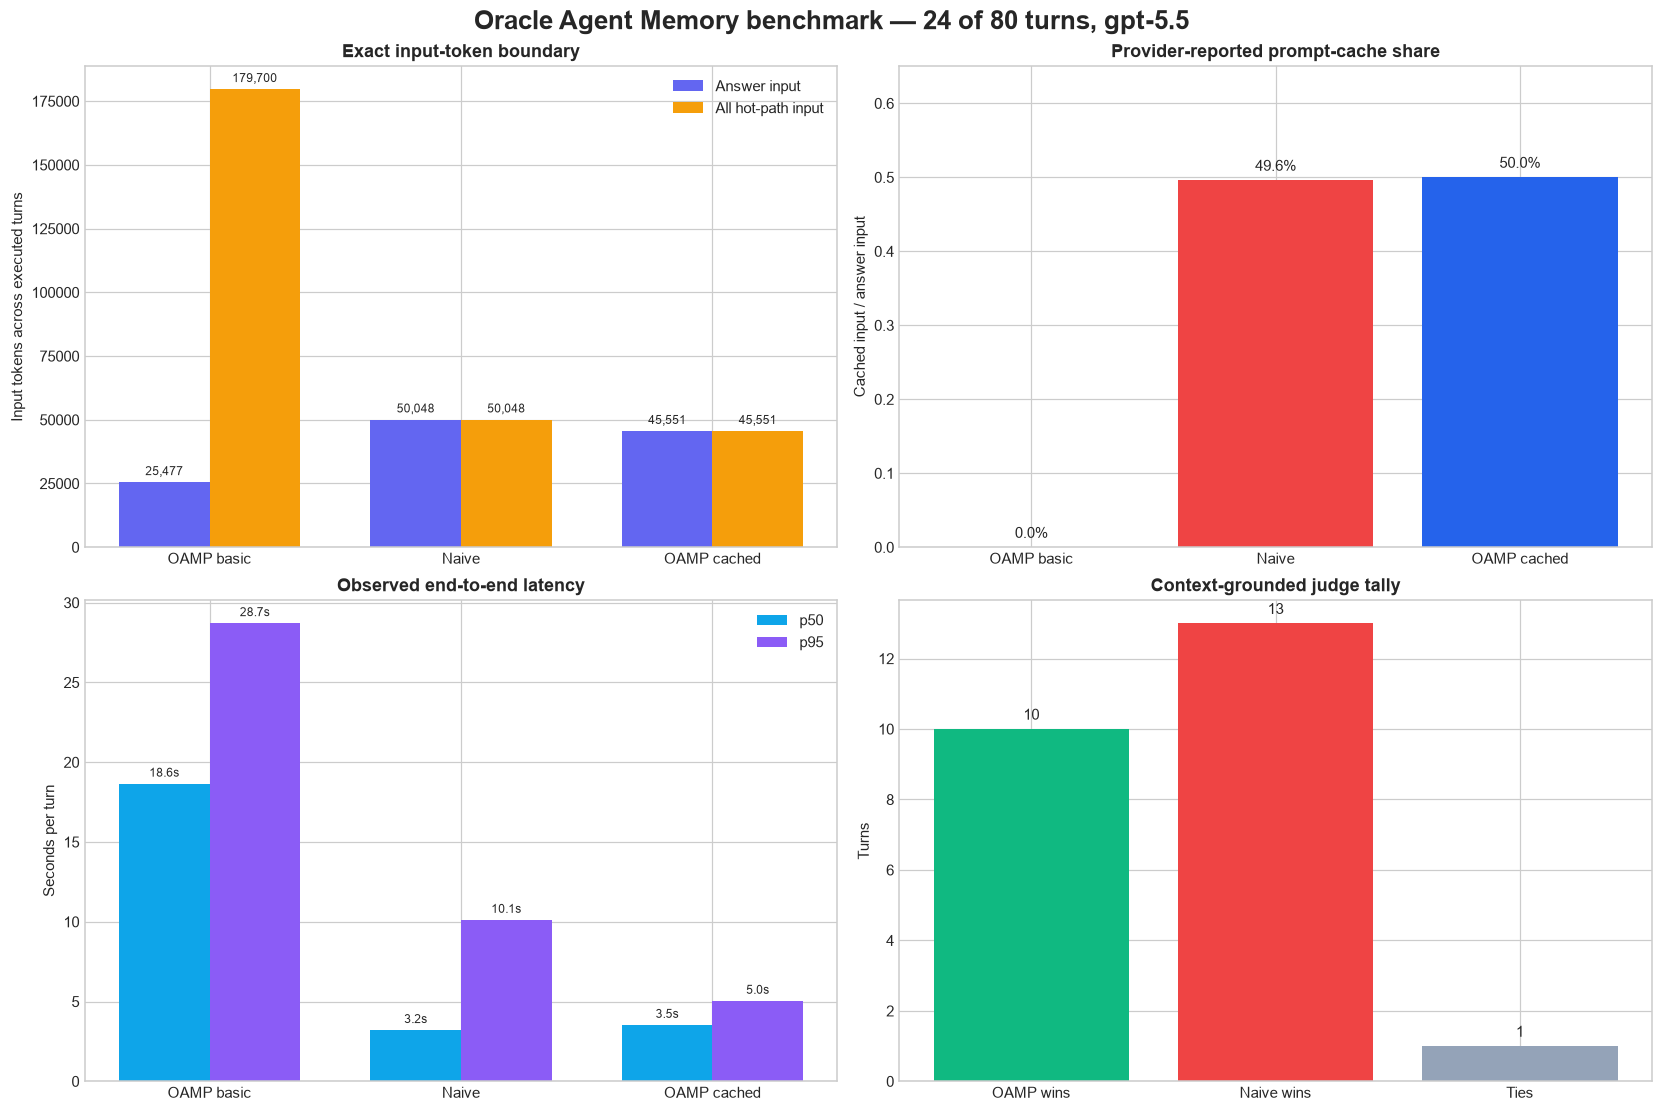

In [16]:
# VISUALIZATION: benchmark executive dashboard
pattern_labels = ["OAMP basic", "Naive", "OAMP cached"]
pattern_colors = ["#10B981", "#EF4444", "#2563EB"]
answer_input_totals = [
    sum(oamp_token_history),
    sum(naive_token_history),
    sum(cached_token_history),
]
hotpath_input_totals = [
    sum(oamp_hotpath_input_history),
    sum(naive_hotpath_input_history),
    sum(cached_hotpath_input_history),
]
cached_input_totals = [
    sum(oamp_cached_token_history),
    sum(naive_cached_token_history),
    sum(cached_cached_token_history),
]
cache_shares = [
    cached / max(1, total)
    for cached, total in zip(cached_input_totals, answer_input_totals)
]
latency_series = [oamp_total_latency, naive_total_latency, cached_total_latency]
p50_latency = [float(np.percentile(values, 50)) for values in latency_series]
p95_latency = [float(np.percentile(values, 95)) for values in latency_series]

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
x = np.arange(len(pattern_labels))

token_ax = axes[0, 0]
width = 0.36
answer_bars = token_ax.bar(
    x - width / 2, answer_input_totals, width, color="#6366F1", label="Answer input"
)
hotpath_bars = token_ax.bar(
    x + width / 2, hotpath_input_totals, width, color="#F59E0B", label="All hot-path input"
)
token_ax.set_title("Exact input-token boundary")
token_ax.set_ylabel("Input tokens across executed turns")
token_ax.set_xticks(x, pattern_labels)
token_ax.legend(frameon=False)
token_ax.bar_label(answer_bars, labels=[f"{value:,}" for value in answer_input_totals], padding=3, fontsize=8)
token_ax.bar_label(hotpath_bars, labels=[f"{value:,}" for value in hotpath_input_totals], padding=3, fontsize=8)

cache_ax = axes[0, 1]
cache_bars = cache_ax.bar(pattern_labels, cache_shares, color=pattern_colors)
cache_ax.set_title("Provider-reported prompt-cache share")
cache_ax.set_ylabel("Cached input / answer input")
cache_ax.set_ylim(0, max(0.65, max(cache_shares) * 1.2))
cache_ax.bar_label(cache_bars, labels=[f"{value:.1%}" for value in cache_shares], padding=4)

latency_ax = axes[1, 0]
p50_bars = latency_ax.bar(x - width / 2, p50_latency, width, color="#0EA5E9", label="p50")
p95_bars = latency_ax.bar(x + width / 2, p95_latency, width, color="#8B5CF6", label="p95")
latency_ax.set_title("Observed end-to-end latency")
latency_ax.set_ylabel("Seconds per turn")
latency_ax.set_xticks(x, pattern_labels)
latency_ax.legend(frameon=False)
latency_ax.bar_label(p50_bars, labels=[f"{value:.1f}s" for value in p50_latency], padding=3, fontsize=8)
latency_ax.bar_label(p95_bars, labels=[f"{value:.1f}s" for value in p95_latency], padding=3, fontsize=8)

quality_ax = axes[1, 1]
quality_labels = ["OAMP wins", "Naive wins", "Ties"]
quality_values = [wins["OAMP"], wins["Naive"], wins["Tie"]]
quality_bars = quality_ax.bar(quality_labels, quality_values, color=["#10B981", "#EF4444", "#94A3B8"])
quality_ax.set_title("Context-grounded judge tally")
quality_ax.set_ylabel("Turns")
quality_ax.bar_label(quality_bars, padding=4)

fig.suptitle(
    f"Oracle Agent Memory benchmark — {len(conversation_turns)} of "
    f"{len(FULL_CONVERSATION_TURNS)} turns, {OPENAI_MODEL}",
    fontsize=17,
    fontweight="bold",
)
plt.show()

### Interpreting the three patterns

| Pattern | Answer context | Hot-path model work | Durable cross-session memory | Best fit |
|---|---|---|---|---|
| Naive | full growing history | one answer call | no | short, process-local sessions |
| OAMP basic | retrieved context card | answer plus synchronous extraction/summary | yes | compact prompts where maintenance latency is acceptable |
| OAMP cached | growing history with scheduled compaction | one answer call; extraction later | yes | latency-sensitive durable agents |

The saved measurements belong to this model alias/snapshot, prompt set, database, network path, and run time. Re-run under your own concurrency and topology, compare p50/p95 rather than only averages, and add human review for release decisions.

## Cleanup

In [17]:
cleanup_errors = []
try:
    client.delete_thread(thread.thread_id)
except Exception as exc:
    cleanup_errors.append(f"basic OAMP thread: {exc}")

try:
    cached_client.delete_thread(cached_thread.thread_id)
except Exception as exc:
    cleanup_errors.append(f"cached OAMP thread: {exc}")

for db_connection in [cached_connection, connection]:
    try:
        db_connection.close()
    except Exception as exc:
        cleanup_errors.append(f"connection close: {exc}")

if cleanup_errors:
    print("Cleanup completed with non-fatal messages:")
    for error in cleanup_errors:
        print(f"  - {error}")
else:
    print("Temporary benchmark threads deleted and both Oracle connections closed.")

Temporary benchmark threads deleted and both Oracle connections closed.
